# PaliGemma 2 3B — Ugandan Meme Generation Evaluation

**Corrected and reorganized version**

This version standardizes the prediction schema, validates evaluation inputs, and uses explicit PaliGemma image tokens consistently.


## Purpose
This notebook evaluates **PaliGemma 2 3B** using the **already prepared UgMeme Training Dataset v1** produced by the shared data-preparation notebook.

**Do not clean, OCR, deduplicate, mask captions, resize the stored dataset, or create new train/validation/test splits in this notebook.**

The shared preparation notebook has already produced the model-ready contract:

- `ugmeme_training_v1/train.csv`
- `ugmeme_training_v1/validation.csv`
- `ugmeme_training_v1/test.csv`
- `ugmeme_training_v1/train.jsonl`
- `ugmeme_training_v1/validation.jsonl`
- `ugmeme_training_v1/test.jsonl`
- `ugmeme_training_v1/images/`
- `ugmeme_training_v1/DATASET_CARD.md`
- `ugmeme_training_v1/preprocessing_summary.json`

The same saved Kaggle dataset version must be attached to **Qwen2.5-VL, PaliGemma 2, InternVL2.5, LLaVA-OneVision and MiniCPM-V**.

The experiment has two matched states:

1. **Zero-shot baseline** on the prepared held-out test split.
2. **QLoRA fine-tuning** on the prepared training split, followed by evaluation on that same held-out test split.

The default checkpoint is `google/paligemma2-3b-mix-224`.

> PaliGemma is gated on Hugging Face. Accept the model license and add a Kaggle secret named `HF_TOKEN` before loading the model.


# 1. Kaggle Setup, Authentication and Reproducibility

Run this notebook on Kaggle with a GPU accelerator.

The experimental comparison is controlled by keeping the following fixed across model notebooks:

- the **same saved UgMeme dataset version**;
- the **same prepared train/validation/test splits**;
- the **same random seed**;
- the **same reduced/full sampling policy**;
- the **same held-out test examples**;
- the **same evaluation metrics**;
- the **same common meme renderer**;
- the **same human-evaluation protocol**.

Only the model-specific processor, architecture and fine-tuning implementation should differ.


In [1]:
import sys
import subprocess

packages = [
    "transformers>=4.47",
    "datasets",
    "accelerate",
    "peft",
    "bitsandbytes",
    "huggingface_hub",
    "sentence-transformers",
    "sacrebleu",
    "rouge-score",
    "scipy",
]

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-U", *packages]
)

print("Dependencies installed/updated.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires scipy<1.17,>=1.8, but you have scipy 1.18.1 which is incompatible.


Dependencies installed/updated.


In [2]:
import sys
import os

# 1. Force python to un-cache and completely forget the old huggingface packages
corrupted_modules = [name for name in sys.modules if name.startswith("huggingface_hub")]
for module in corrupted_modules:
    del sys.modules[module]

# 2. Add an explicit local target directory check
if "/usr/local/lib/python3.12/dist-packages" not in sys.path:
    sys.path.insert(0, "/usr/local/lib/python3.12/dist-packages")

# 3. Import and execute directly from the pristine memory state
try:
    from huggingface_hub import HfApi, login
    print("🚀 Success! Huggingface Hub imported perfectly.")
except ImportError:
    # Fallback to absolute programmatic reloading if internal bindings are stubborn
    import importlib
    import huggingface_hub
    importlib.reload(huggingface_hub)
    from huggingface_hub import HfApi, login
    print("🔄 Dynamic Reload Success! Ready to use.")


🚀 Success! Huggingface Hub imported perfectly.


In [3]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import HfApi, login

# Get Hugging Face token from Kaggle Secrets
secrets = UserSecretsClient()
HF_TOKEN = secrets.get_secret("HF_TOKEN")

# Authenticate
login(
    token=HF_TOKEN,
    add_to_git_credential=False
)

# Verify account
api = HfApi(token=HF_TOKEN)
user_info = api.whoami()

print("✓ Hugging Face login successful")
print("✓ Logged in as:", user_info["name"])

# Verify access to gated PaliGemma model
MODEL_ID = "google/paligemma2-3b-mix-224"

try:
    info = api.model_info(
        MODEL_ID,
        token=HF_TOKEN
    )

    print("✓ PaliGemma access confirmed")
    print("✓ Model:", info.id)

except Exception as e:
    print("✗ PaliGemma access failed")
    print(type(e).__name__)
    print(e)
    

✓ Hugging Face login successful
✓ Logged in as: Mwizerwa
✓ PaliGemma access confirmed
✓ Model: google/paligemma2-3b-mix-224


In [4]:
import os
import sys
import gc
import re
import json
import time
import math
import random
import hashlib
import inspect
import platform
import subprocess
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

import torch
import transformers
import datasets
import peft
import bitsandbytes as bnb
from huggingface_hub import login

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False

# -----------------------------------------------------------
# MODEL
# -----------------------------------------------------------
# Default: ready-to-use PaliGemma 2 Mix checkpoint for a fairer zero-shot
# comparison with an instruction-ready model such as Qwen2.5-VL.
MODEL_ID = "google/paligemma2-3b-mix-224"
# Alternative transfer-oriented checkpoint:
# MODEL_ID = "google/paligemma2-3b-pt-224"

MODEL_LABEL = "PaliGemma 2 3B Mix 224"
EXPERIMENT_NAME = "paligemma2_3b_mix224_ugmeme"

OUTPUT_ROOT = Path("/kaggle/working/paligemma2_3b_results")
ADAPTER_DIR = OUTPUT_ROOT / "adapter"
FIGURE_DIR = OUTPUT_ROOT / "figures"
RENDER_DIR = OUTPUT_ROOT / "rendered_memes"

for folder in [OUTPUT_ROOT, ADAPTER_DIR, FIGURE_DIR, RENDER_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------
# RUN MODE — use the same setting as the Qwen experiment
# -----------------------------------------------------------
RUN_MODE = "reduced"      # MUST match Qwen: "reduced" pilot or "full" final

if RUN_MODE == "reduced":
    TRAIN_LIMIT = 600
    VAL_LIMIT = 100
    TEST_LIMIT = 100
    NUM_EPOCHS = 1
else:
    TRAIN_LIMIT = None
    VAL_LIMIT = None
    TEST_LIMIT = None
    NUM_EPOCHS = 3

MAX_NEW_TOKENS = 80
DO_SAMPLE = False

# PaliGemma 2 checkpoint resolution used here.
IMAGE_RESOLUTION = 224

# Human evaluation settings
HUMAN_EVAL_N = 50
N_RATER_SLOTS = 3

SUCCESS_THRESHOLDS = {
    "visual_relevance_1_5": 4.0,
    "ugandan_cultural_appropriateness_1_5": 4.0,
    "humour_1_5": 3.0,
    "communicative_effectiveness_1_5": 4.0,
    "typography_readability_1_5": 4.0,
    "layout_quality_1_5": 4.0,
}

# -----------------------------------------------------------
# Hugging Face authentication for the gated PaliGemma model.
# 1. Accept the model license on Hugging Face.
# 2. Add a Kaggle secret named HF_TOKEN.
# -----------------------------------------------------------
hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")

if not hf_token:
    try:
        from kaggle_secrets import UserSecretsClient
        hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        hf_token = None

if hf_token:
    login(token=hf_token, add_to_git_credential=False)
    print("Hugging Face authentication completed.")
else:
    print(
        "WARNING: HF_TOKEN was not found. PaliGemma is gated. "
        "Accept the license and add HF_TOKEN as a Kaggle secret before model loading."
    )

print("Run mode:", RUN_MODE)
print("Model:", MODEL_ID)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("PEFT:", peft.__version__)
print("bitsandbytes:", bnb.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory (GB):",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2)
    )
else:
    raise RuntimeError(
        "A CUDA GPU is required. Enable a GPU accelerator in Kaggle Notebook Settings."
    )


Hugging Face authentication completed.
Run mode: reduced
Model: google/paligemma2-3b-mix-224
Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA version: 12.8
Transformers: 5.17.0
Datasets: 5.0.1
PEFT: 0.21.0
bitsandbytes: 0.50.2
CUDA available: True
GPU: Tesla T4
GPU memory (GB): 14.56


# 2. Load the Prepared UgMeme Dataset — No Reprocessing

The shared data-preparation notebook already created a leakage-controlled dataset.

Expected model-ready CSV columns include:

- `sample_id`
- `image_path`
- `prompt`
- `target_caption`
- `split`
- `visual_group`

The preparation notebook also retains provenance and quality metadata.

The fixed learning task is:

**Input:** leakage-reduced meme image + prepared meme-generation prompt  
**Target:** OCR-derived candidate meme caption

PaliGemma's processor may resize/normalize an image internally to the checkpoint's required input resolution during batching. That is **model-side preprocessing only** and does not modify the shared prepared dataset.


In [5]:
INPUT_ROOT = Path("/kaggle/input")

# -----------------------------------------------------------
# Locate ONE complete saved output from the shared UgMeme
# preparation notebook. We anchor on DATASET_CARD.md instead
# of independently searching for three CSV files, which avoids
# accidentally mixing files from different Kaggle inputs.
# -----------------------------------------------------------
dataset_card_candidates = list(INPUT_ROOT.rglob("DATASET_CARD.md"))

if not dataset_card_candidates:
    raise FileNotFoundError(
        "DATASET_CARD.md was not found under /kaggle/input. "
        "Attach the saved output of the shared UgMeme data-preparation notebook."
    )

preferred_cards = [
    p for p in dataset_card_candidates
    if p.parent.name == "ugmeme_training_v1"
    or "ugmeme_training_v1" in str(p.parent)
]

DATASET_CARD = preferred_cards[0] if preferred_cards else dataset_card_candidates[0]
DATASET_ROOT = DATASET_CARD.parent

TRAIN_CSV = DATASET_ROOT / "train.csv"
VAL_CSV = DATASET_ROOT / "validation.csv"
TEST_CSV = DATASET_ROOT / "test.csv"
PREPROCESSING_SUMMARY = DATASET_ROOT / "preprocessing_summary.json"
IMAGE_DIR = DATASET_ROOT / "images"

required_prepared_files = [
    TRAIN_CSV,
    VAL_CSV,
    TEST_CSV,
    DATASET_CARD,
    PREPROCESSING_SUMMARY,
]

missing = [str(p) for p in required_prepared_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "The attached prepared dataset is incomplete. Missing:\n"
        + "\n".join(missing)
    )

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Prepared image directory not found: {IMAGE_DIR}")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

with open(PREPROCESSING_SUMMARY, "r", encoding="utf-8") as f:
    preprocessing_summary = json.load(f)

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

dataset_hashes = {
    "train_csv_sha256": sha256_file(TRAIN_CSV),
    "validation_csv_sha256": sha256_file(VAL_CSV),
    "test_csv_sha256": sha256_file(TEST_CSV),
}

print("=" * 72)
print("PREPARED UgMeme DATASET ATTACHED")
print("=" * 72)
print("Dataset root:", DATASET_ROOT)
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Preparation seed:", preprocessing_summary.get("seed"))
print("Training-ready total:", preprocessing_summary.get("training_ready_total"))
print("CSV SHA-256 hashes recorded for cross-model reproducibility.")


PREPARED UgMeme DATASET ATTACHED
Dataset root: /kaggle/input/notebooks/johntoms/complete-ugmeme-data-preparation-pipeline/ugmeme_training_v1
Train: 1817
Validation: 387
Test: 384
Preparation seed: 42
Training-ready total: 2588
CSV SHA-256 hashes recorded for cross-model reproducibility.


In [6]:
REQUIRED_COLUMNS = {
    "sample_id",
    "image_path",
    "prompt",
    "target_caption",
    "split",
}

frames = {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}

# 1. Required schema and split identity
for expected_split, df in frames.items():
    missing_cols = REQUIRED_COLUMNS - set(df.columns)
    if missing_cols:
        raise ValueError(
            f"{expected_split} CSV is missing columns: {missing_cols}"
        )

    actual_split_values = set(df["split"].astype(str).str.lower().unique())
    if actual_split_values != {expected_split}:
        raise ValueError(
            f"{expected_split}.csv has unexpected split values: "
            f"{actual_split_values}"
        )

# 2. All image paths must resolve inside the prepared dataset
for name, df in frames.items():
    missing_images = [
        str(rel)
        for rel in df["image_path"]
        if not (DATASET_ROOT / str(rel)).exists()
    ]
    if missing_images:
        raise FileNotFoundError(
            f"{name} contains {len(missing_images)} missing prepared images. "
            f"First missing path: {missing_images[0]}"
        )

# 3. Sample IDs must be unique within and across splits
for name, df in frames.items():
    if not df["sample_id"].is_unique:
        raise ValueError(f"Duplicate sample_id values found inside {name}.")

train_ids = set(train_df["sample_id"].astype(str))
val_ids = set(val_df["sample_id"].astype(str))
test_ids = set(test_df["sample_id"].astype(str))

assert train_ids.isdisjoint(val_ids), "Train/validation sample leakage detected."
assert train_ids.isdisjoint(test_ids), "Train/test sample leakage detected."
assert val_ids.isdisjoint(test_ids), "Validation/test sample leakage detected."

# 4. Re-check prepared visual-group separation when available
if all("visual_group" in df.columns for df in frames.values()):
    train_groups = set(train_df["visual_group"].dropna().astype(str))
    val_groups = set(val_df["visual_group"].dropna().astype(str))
    test_groups = set(test_df["visual_group"].dropna().astype(str))

    assert train_groups.isdisjoint(val_groups), "Train/validation visual-group leakage."
    assert train_groups.isdisjoint(test_groups), "Train/test visual-group leakage."
    assert val_groups.isdisjoint(test_groups), "Validation/test visual-group leakage."

# 5. Prompts and targets must remain populated
for name, df in frames.items():
    if not df["prompt"].fillna("").astype(str).str.strip().ne("").all():
        raise ValueError(f"Blank prompt found in {name}.")
    if not df["target_caption"].fillna("").astype(str).str.strip().ne("").all():
        raise ValueError(f"Blank target_caption found in {name}.")

# 6. Confirm the preparation notebook's saved leakage audit when present
saved_audit = preprocessing_summary.get("split_leakage_audit", {})
if saved_audit:
    failed_saved_checks = {k: v for k, v in saved_audit.items() if v != 0}
    if failed_saved_checks:
        raise ValueError(
            "The preparation summary reports leakage. Do not train models. "
            f"Failures: {failed_saved_checks}"
        )

print("=" * 72)
print("PREPARED DATASET VALIDATION PASSED")
print("=" * 72)
print("No re-splitting or re-cleaning will be performed in this notebook.")
print(f"Train: {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test: {len(test_df):,}")


PREPARED DATASET VALIDATION PASSED
No re-splitting or re-cleaning will be performed in this notebook.
Train: 1,817
Validation: 387
Test: 384


## 2.1 Prepared Dataset Audit

This section only **describes** the already prepared dataset. It does not alter the shared data.

For the final five-model comparison, the dataset files and their SHA-256 hashes should be identical across all model experiment manifests.


,split,count
0,Train,1817
1,Validation,387
2,Test,384


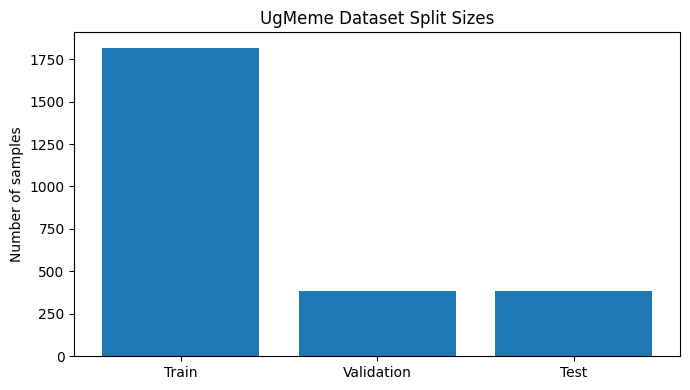

,split,mean_words,median_words
0,Train,11.108971,9.0
1,Validation,11.069767,9.0
2,Test,10.867188,9.0


In [7]:
split_counts = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "count": [len(train_df), len(val_df), len(test_df)]
})

display(split_counts)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(split_counts["split"], split_counts["count"])
ax.set_title("UgMeme Dataset Split Sizes")
ax.set_ylabel("Number of samples")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "dataset_split_sizes.png", dpi=180, bbox_inches="tight")
plt.show()

for frame in [train_df, val_df, test_df]:
    frame["caption_words_modelaudit"] = (
        frame["target_caption"].astype(str).str.split().str.len()
    )

caption_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "mean_words": [
        train_df["caption_words_modelaudit"].mean(),
        val_df["caption_words_modelaudit"].mean(),
        test_df["caption_words_modelaudit"].mean()
    ],
    "median_words": [
        train_df["caption_words_modelaudit"].median(),
        val_df["caption_words_modelaudit"].median(),
        test_df["caption_words_modelaudit"].median()
    ],
})
display(caption_summary)


In [8]:
# -----------------------------------------------------------
# SELECT ACTIVE EXPERIMENT SUBSETS
# -----------------------------------------------------------

# New seed for the training subset on every fresh experiment
RUN_SEED = int.from_bytes(os.urandom(4), "little")

print("Training subset seed:", RUN_SEED)


def take_limit(frame, limit, seed):
    if limit is None or limit >= len(frame):
        return frame.copy().reset_index(drop=True)

    return (
        frame.sample(
            n=limit,
            random_state=seed
        )
        .sort_values("sample_id")
        .reset_index(drop=True)
    )


# Different training samples for each NEW experiment
train_run_df = take_limit(
    train_df,
    TRAIN_LIMIT,
    RUN_SEED
)

# Validation and test remain fixed
val_run_df = take_limit(
    val_df,
    VAL_LIMIT,
    SEED
)

test_run_df = take_limit(
    test_df,
    TEST_LIMIT,
    SEED
)


print("=" * 60)
print("ACTIVE EXPERIMENT SIZES")
print("=" * 60)

print("Train:", len(train_run_df))
print("Validation:", len(val_run_df))
print("Test:", len(test_run_df))
print("Training subset seed:", RUN_SEED)

Training subset seed: 1380033306
ACTIVE EXPERIMENT SIZES
Train: 600
Validation: 100
Test: 100
Training subset seed: 1380033306


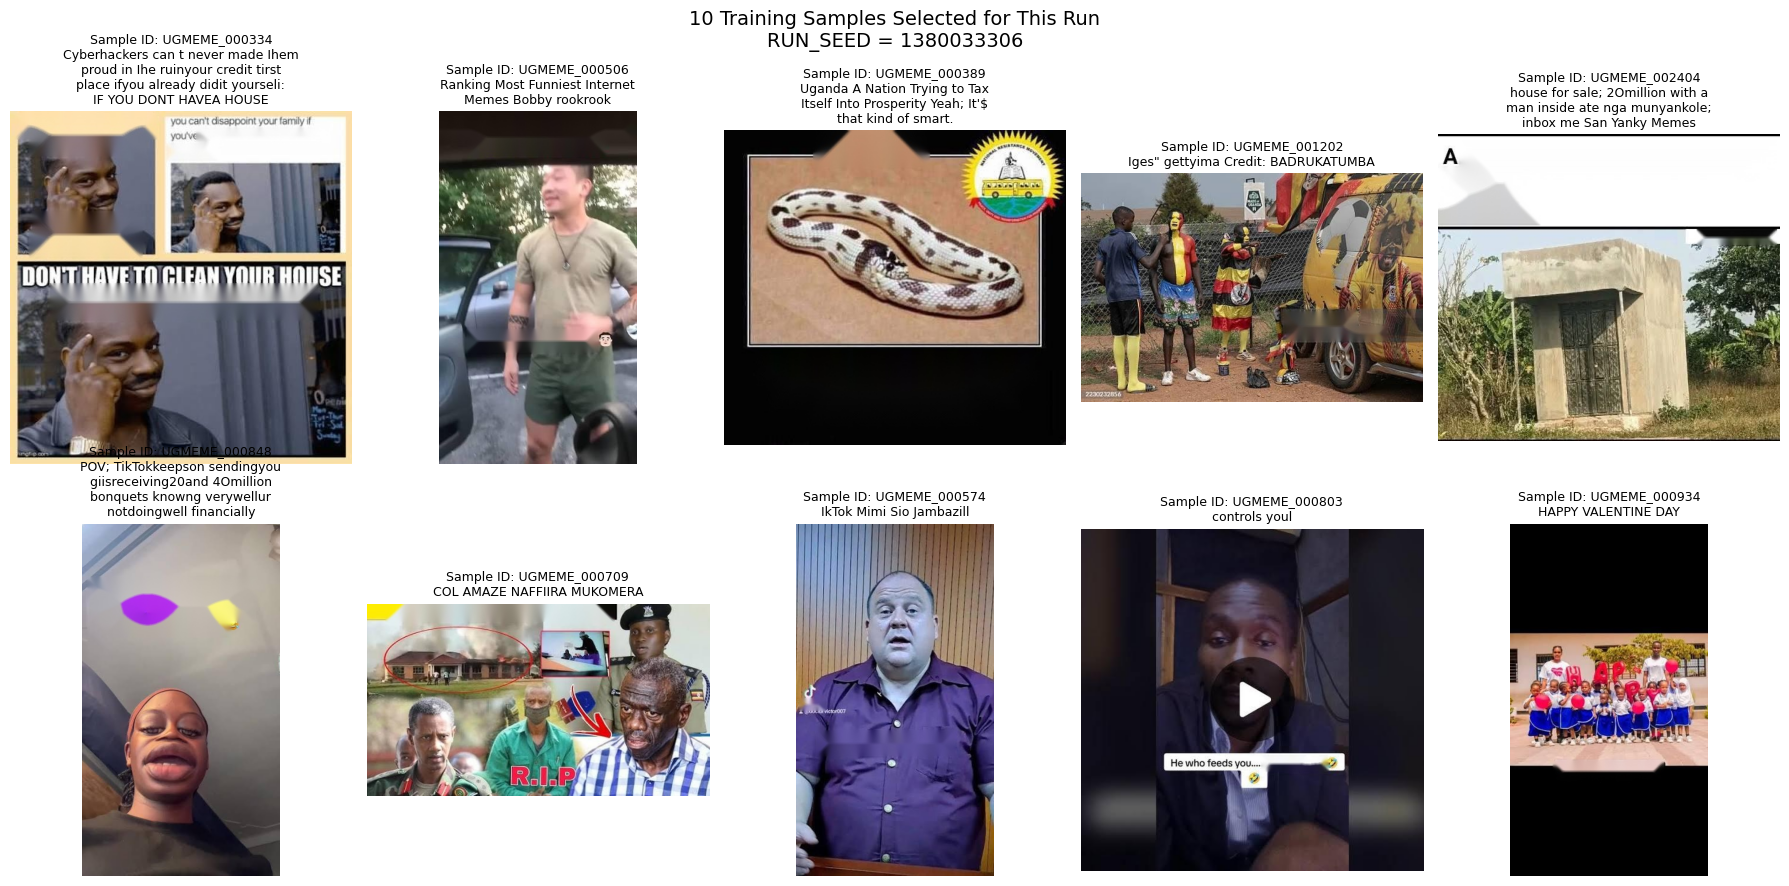

Preview saved to:
/kaggle/working/paligemma2_3b_results/figures/training_subset_preview_seed_1380033306.png


In [9]:
# -----------------------------------------------------------
# VISUAL CONFIRMATION OF SELECTED TRAINING SUBSET
# -----------------------------------------------------------

PREVIEW_N = 10

# Select 10 examples from the ACTIVE training subset
preview_df = train_run_df.sample(
    n=min(PREVIEW_N, len(train_run_df)),
    random_state=RUN_SEED
).reset_index(drop=True)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 9)
)

axes = axes.flatten()

for i, ax in enumerate(axes):

    if i >= len(preview_df):
        ax.axis("off")
        continue

    row = preview_df.iloc[i]

    image_path = DATASET_ROOT / str(row["image_path"])

    try:
        image = Image.open(image_path).convert("RGB")

        ax.imshow(image)

        caption = str(row["target_caption"])

        # Keep caption readable
        short_caption = textwrap.fill(
            caption,
            width=35
        )

        ax.set_title(
            f"Sample ID: {row['sample_id']}\n"
            f"{short_caption}",
            fontsize=9
        )

        ax.axis("off")

    except Exception as e:
        ax.text(
            0.5,
            0.5,
            f"Image failed to load\n{image_path.name}\n{e}",
            ha="center",
            va="center"
        )

        ax.axis("off")


plt.suptitle(
    f"10 Training Samples Selected for This Run\n"
    f"RUN_SEED = {RUN_SEED}",
    fontsize=14
)

plt.tight_layout()

PREVIEW_FILE = (
    FIGURE_DIR /
    f"training_subset_preview_seed_{RUN_SEED}.png"
)

fig.savefig(
    PREVIEW_FILE,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Preview saved to:")
print(PREVIEW_FILE)

# 3. Load PaliGemma 2 and Record Model Size

The same PaliGemma checkpoint is first evaluated **zero-shot**, then fine-tuned with QLoRA. The model uses a SigLIP-family vision encoder and a Gemma 2 language decoder. We use 4-bit NF4 loading to make the 3B checkpoint practical on Kaggle GPUs.


In [10]:
from transformers import AutoProcessor, BitsAndBytesConfig, PaliGemmaForConditionalGeneration

compute_dtype = (
    torch.bfloat16 if torch.cuda.is_bf16_supported()
    else torch.float16
)

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    token=hf_token,
)

# Right padding is appropriate for supervised prompt+suffix batching.
if hasattr(processor, "tokenizer"):
    processor.tokenizer.padding_side = "right"

model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=quant_config,
    device_map={"": 0},
    torch_dtype=compute_dtype,
    token=hf_token,
)

model.eval()

def parameter_counts(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return {
        "total_parameters": int(total),
        "trainable_parameters_before_lora": int(trainable),
    }

base_parameter_stats = parameter_counts(model)
display(pd.DataFrame([base_parameter_stats]))


preprocessor_config.json:   0%|          | 0.00/424 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/243k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 34.6MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

,total_parameters,trainable_parameters_before_lora
0,1813242096,594241776


# 4. Deterministic Meme-Caption Generation

Greedy decoding is used so repeated runs are comparable. PaliGemma receives **the same image and prompt field used in the Qwen experiment**. No PaliGemma-specific task instruction is inserted here because that would change the experimental input. The processor performs PaliGemma's required image/text formatting.


In [11]:
def format_prompt(prompt):
    """Return the semantic text prompt exactly as stored in the prepared dataset."""
    return str(prompt).strip()

def format_multimodal_prompt(prompt):
    """Add the image token expected by PaliGemma when text and an image are provided."""
    return "<image>" + format_prompt(prompt)

@torch.inference_mode()
def generate_caption(
    active_model,
    image_path,
    prompt,
    max_new_tokens=MAX_NEW_TOKENS
):
    image = Image.open(image_path).convert("RGB")
    prompt_text = format_multimodal_prompt(prompt)

    inputs = processor(
        images=image,
        text=prompt_text,
        return_tensors="pt"
    )

    device = next(active_model.parameters()).device
    moved = {}
    for k, v in inputs.items():
        if hasattr(v, "to"):
            if k == "pixel_values":
                moved[k] = v.to(device=device, dtype=compute_dtype)
            else:
                moved[k] = v.to(device)
        else:
            moved[k] = v
    inputs = moved

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()

    generated_ids = active_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=DO_SAMPLE,
        use_cache=True,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    # PaliGemma generation includes the input prefix; decode only newly generated tokens.
    input_length = inputs["input_ids"].shape[-1]
    new_tokens = generated_ids[:, input_length:]

    caption = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    return caption, elapsed


In [12]:
# Qualitative zero-shot test on several examples

N_EXAMPLES = 5

smoke_samples = test_run_df.sample(
    n=min(N_EXAMPLES, len(test_run_df)),
    random_state=SEED
)

smoke_results = []

for i, (_, sample) in enumerate(smoke_samples.iterrows(), start=1):

    image_path = DATASET_ROOT / sample["image_path"]

    generated, latency = generate_caption(
        model,
        image_path,
        sample["prompt"]
    )

    smoke_results.append({
        "sample_id": sample["sample_id"],
        "reference": sample["target_caption"],
        "generated": generated,
        "latency_seconds": latency
    })

    print("=" * 80)
    print(f"EXAMPLE {i}")
    print("Reference:")
    print(sample["target_caption"])

    print("\nPaliGemma generated:")
    print(generated)

    print(f"\nLatency: {latency:.2f} seconds")

print("=" * 80)
print(
    "Average latency:",
    round(
        sum(r["latency_seconds"] for r in smoke_results)
        / len(smoke_results),
        2
    ),
    "seconds"
)


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (4304) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


EXAMPLE 1
Reference:
TEACHER: Name six Animals that live WFI inside water PP STUDENT : Frog TEACHER: Name the other five STUDENT: The father; mother; Frog brothers; sisters and cousins

PaliGemma generated:
Sorry, as a base VLM I am not trained to answer this question.

Latency: 2.45 seconds
EXAMPLE 2
Reference:
Funniest memes part six

PaliGemma generated:
Sorry, as a base VLM I am not trained to answer this question.

Latency: 1.62 seconds
EXAMPLE 3
Reference:
Apart from joblessness, Selling family lands, Reading of newspapers, And having much interest in court cases and much talking; What other things do you know about uncles that wear this cap?

PaliGemma generated:
Sorry, as a base VLM I am not trained to answer this question.

Latency: 1.64 seconds
EXAMPLE 4
Reference:
20 Most Famous Ugandan Celebrities

PaliGemma generated:
Sorry, as a base VLM I am not trained to answer this question.

Latency: 1.63 seconds
EXAMPLE 5
Reference:
Nga wakazukuka Soka osabe mukama Proverbs 3:6 wesi

# 5. Zero-Shot Held-Out Test

This is the baseline. It is generated **before fine-tuning** on the same held-out test examples used later.


In [13]:
ZERO_SHOT_PATH = OUTPUT_ROOT / "zero_shot_test_predictions.csv"

rows = []

for n, (_, row) in enumerate(test_run_df.iterrows(), start=1):
    image_path = DATASET_ROOT / row["image_path"]

    prediction, latency = generate_caption(
        model,
        image_path,
        row["prompt"]
    )

    rows.append({
        "sample_id": row["sample_id"],
        "image_path": row["image_path"],
        "prompt": row["prompt"],
        "reference": row["target_caption"],
        "prediction": prediction,
        "latency_seconds": latency
    })

    if n % 10 == 0 or n == len(test_run_df):
        print(f"Zero-shot: {n}/{len(test_run_df)}")

zero_shot_df = pd.DataFrame(rows)
zero_shot_df.to_csv(ZERO_SHOT_PATH, index=False)

print("Zero-shot predictions saved:", ZERO_SHOT_PATH)
print("Columns:", zero_shot_df.columns.tolist())



Zero-shot: 10/100
Zero-shot: 20/100
Zero-shot: 30/100
Zero-shot: 40/100
Zero-shot: 50/100
Zero-shot: 60/100
Zero-shot: 70/100
Zero-shot: 80/100
Zero-shot: 90/100
Zero-shot: 100/100
Zero-shot predictions saved: /kaggle/working/paligemma2_3b_results/zero_shot_test_predictions.csv
Columns: ['sample_id', 'image_path', 'prompt', 'reference', 'prediction', 'latency_seconds']


# 6. Adapt the Prepared UgMeme Records to PaliGemma's Training Interface

No new data preparation occurs here.

The rows come directly from the prepared `train.csv` and `validation.csv`. This section only converts those fixed records into the input structure expected by PaliGemma:

- `image` = prepared leakage-reduced image referenced by `image_path`;
- `prompt` = the exact prepared prompt stored in the CSV;
- `target_caption` = the exact prepared target caption stored in the CSV.

PaliGemma's processor supports a `suffix` argument during supervised fine-tuning. The suffix becomes the target labels while the prepared image and prompt remain the conditioning input.

This model-specific formatting is allowed; changing the underlying samples, prompts, targets or split membership is not.


In [14]:
from datasets import Dataset, Image as HFImage

def make_paligemma_dataset(frame):
    records = []

    for _, row in frame.iterrows():
        absolute_image = str(
            (DATASET_ROOT / row["image_path"]).resolve()
        )

        records.append({
            "sample_id": str(row["sample_id"]),
            "image": absolute_image,
            "prompt": format_prompt(row["prompt"]),
            "target_caption": str(row["target_caption"]).strip(),
        })

    ds = Dataset.from_list(records)
    ds = ds.cast_column("image", HFImage())
    return ds

hf_train = make_paligemma_dataset(train_run_df)
hf_val = make_paligemma_dataset(val_run_df)

print(hf_train)
print(hf_val)
print("\nFirst training record keys:", hf_train[0].keys())

def paligemma_collate_fn(examples):
    images = [ex["image"].convert("RGB") for ex in examples]
    prompts = [format_multimodal_prompt(ex["prompt"]) for ex in examples]
    answers = [str(ex["target_caption"]).strip() for ex in examples]

    batch = processor(
        images=images,
        text=prompts,
        suffix=answers,
        return_tensors="pt",
        padding="longest",
    )
    return batch

example_batch = paligemma_collate_fn([hf_train[0]])
print("Collated keys:", example_batch.keys())
print("input_ids shape:", tuple(example_batch["input_ids"].shape))
print("pixel_values shape:", tuple(example_batch["pixel_values"].shape))
print("labels shape:", tuple(example_batch["labels"].shape))


Dataset({
    features: ['sample_id', 'image', 'prompt', 'target_caption'],
    num_rows: 600
})
Dataset({
    features: ['sample_id', 'image', 'prompt', 'target_caption'],
    num_rows: 100
})

First training record keys: dict_keys(['sample_id', 'image', 'prompt', 'target_caption'])
Collated keys: KeysView({'input_ids': tensor([[257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 2571

QLoRA (Quantized Low-Rank Adaptation) fine-tunes a small set of adapter parameters while the 3B base model stays quantized. This keeps the PaliGemma experiment feasible on Kaggle while preserving the same parameter-efficient training philosophy used for Qwen. The target modules follow the standard Gemma/PaliGemma projection layers used in Hugging Face's PaliGemma LoRA examples.


In [15]:
from peft import (
    LoraConfig,
    prepare_model_for_kbit_training,
    get_peft_model,
)

model.config.use_cache = False

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ]
)

model = get_peft_model(model, lora_config)

print("QLoRA configuration ready.")
print("LoRA rank:", lora_config.r)
print("LoRA alpha:", lora_config.lora_alpha)
print("LoRA dropout:", lora_config.lora_dropout)
print("Target modules:", sorted(lora_config.target_modules))
model.print_trainable_parameters()


QLoRA configuration ready.
LoRA rank: 16
LoRA alpha: 32
LoRA dropout: 0.05
Target modules: ['down_proj', 'gate_proj', 'k_proj', 'o_proj', 'q_proj', 'up_proj', 'v_proj']
trainable params: 23,752,704 || all params: 3,055,995,120 || trainable%: 0.7772


In [16]:
# -----------------------------------------------------------
# VERIFY THAT ONLY LORA PARAMETERS ARE TRAINABLE
# -----------------------------------------------------------

trainable_names = []
unexpected_trainable = []

for name, param in model.named_parameters():

    if param.requires_grad:
        trainable_names.append(name)

        if "lora_" not in name.lower():
            unexpected_trainable.append(name)


print("=" * 72)
print("QLoRA TRAINABLE PARAMETER CHECK")
print("=" * 72)

print("Number of trainable parameter tensors:", len(trainable_names))

print("\nFirst 20 trainable parameter names:")
for name in trainable_names[:20]:
    print("  ", name)


if unexpected_trainable:
    print("\n⚠ WARNING: Non-LoRA parameters are trainable:")

    for name in unexpected_trainable[:20]:
        print("  ", name)

else:
    print("\n✓ Only LoRA adapter parameters are trainable.")


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTotal parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")
print(
    "Trainable percentage:",
    f"{100 * trainable_params / total_params:.4f}%"
)

QLoRA TRAINABLE PARAMETER CHECK
Number of trainable parameter tensors: 526

First 20 trainable parameter names:
   base_model.model.model.vision_tower.encoder.layers.0.self_attn.k_proj.lora_A.default.weight
   base_model.model.model.vision_tower.encoder.layers.0.self_attn.k_proj.lora_B.default.weight
   base_model.model.model.vision_tower.encoder.layers.0.self_attn.v_proj.lora_A.default.weight
   base_model.model.model.vision_tower.encoder.layers.0.self_attn.v_proj.lora_B.default.weight
   base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.lora_A.default.weight
   base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.lora_B.default.weight
   base_model.model.model.vision_tower.encoder.layers.1.self_attn.k_proj.lora_A.default.weight
   base_model.model.model.vision_tower.encoder.layers.1.self_attn.k_proj.lora_B.default.weight
   base_model.model.model.vision_tower.encoder.layers.1.self_attn.v_proj.lora_A.default.weight
   base_model.model.model.vision_

## 6.1 Training Configuration

For the final five-model comparison, record model-specific constraints but keep the dataset, evaluation split and reporting metrics fixed.


In [17]:
training_hyperparameters = {
    "run_mode": RUN_MODE,

    # Dataset
    "train_samples": len(train_run_df),
    "validation_samples": len(val_run_df),
    "test_samples": len(test_run_df),

    # Seeds
    "global_seed": SEED,
    "training_subset_seed": RUN_SEED,

    # Training
    "epochs": NUM_EPOCHS,
    "train_batch_size": 1,
    "eval_batch_size": 1,
    "gradient_accumulation_steps": 8,
    "effective_batch_size": 8,

    # Optimization
    "learning_rate": 1e-4,
    "weight_decay": 0.01,
    "warmup_ratio": 0.03,
    "lr_scheduler": "cosine",
    "max_grad_norm": 1.0,

    # QLoRA
    "lora_rank": lora_config.r,
    "lora_alpha": lora_config.lora_alpha,
    "lora_dropout": lora_config.lora_dropout,
    "lora_target_modules": ", ".join(
        sorted(lora_config.target_modules)
    ),

    # Quantization
    "quantization": "4-bit NF4",
    "compute_dtype": str(compute_dtype),

    # Model
    "image_resolution": IMAGE_RESOLUTION,
    "checkpoint": MODEL_ID,

    # Memory optimization
    "gradient_checkpointing": True,

    # Hardware
    "gpu": torch.cuda.get_device_name(0),
}

hyperparameter_df = pd.DataFrame(
    training_hyperparameters.items(),
    columns=["Hyperparameter", "Value"]
)

display(hyperparameter_df)

# Save for reproducibility
hyperparameter_df.to_csv(
    OUTPUT_ROOT / "training_hyperparameters.csv",
    index=False
)

print(
    "Hyperparameters saved to:",
    OUTPUT_ROOT / "training_hyperparameters.csv"
)

,Hyperparameter,Value
0,run_mode,reduced
1,train_samples,600
2,validation_samples,100
3,test_samples,100
4,global_seed,42
5,training_subset_seed,1380033306
6,epochs,1
7,train_batch_size,1
8,eval_batch_size,1
9,gradient_accumulation_steps,8


Hyperparameters saved to: /kaggle/working/paligemma2_3b_results/training_hyperparameters.csv


In [20]:
from transformers import (
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# -----------------------------------------------------------
# TRAINING ARGUMENTS
# -----------------------------------------------------------

RUN_NAME = f"paligemma2-3b-run-{RUN_SEED}"

training_candidate_kwargs = {

    # Output
    "output_dir": str(
        OUTPUT_ROOT / "checkpoints"
    ),

    # Training duration
    "num_train_epochs": NUM_EPOCHS,

    # Batch sizes
    "per_device_train_batch_size": 1,
    "per_device_eval_batch_size": 1,

    # Effective batch size = 1 × 8 = 8
    "gradient_accumulation_steps": 8,

    # Optimisation
    "learning_rate": 1e-4,
    "weight_decay": 0.01,
    "warmup_ratio": 0.03,
    "lr_scheduler_type": "cosine",
    "max_grad_norm": 1.0,

    # Logging
    "logging_steps": 5,
    "logging_first_step": True,

    # Evaluation / checkpoints
    "save_strategy": "epoch",
    "eval_strategy": "epoch",
    "evaluation_strategy": "epoch",

    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,

    # Memory optimisation
    "gradient_checkpointing": True,
    "gradient_checkpointing_kwargs": {
        "use_reentrant": False
    },

    "optim": "paged_adamw_8bit",

    # -------------------------------------------------------
    # Tesla T4: use FP16
    # -------------------------------------------------------
    "fp16": True,
    "bf16": False,

    # -------------------------------------------------------
    # WEIGHTS & BIASES
    # -------------------------------------------------------
    "report_to": "wandb",
    "run_name": RUN_NAME,

    # Reproducibility
    "seed": SEED,
    "data_seed": SEED,

    # Required for multimodal custom collator
    "remove_unused_columns": False,

    # Safer in Kaggle multimodal training
    "dataloader_num_workers": 0,
    "dataloader_pin_memory": False,

    # Only retain latest two checkpoints
    "save_total_limit": 2,
}


# -----------------------------------------------------------
# TRANSFORMERS VERSION COMPATIBILITY
# -----------------------------------------------------------

accepted = set(
    inspect.signature(
        TrainingArguments.__init__
    ).parameters
)

if "eval_strategy" in accepted:
    training_candidate_kwargs.pop(
        "evaluation_strategy",
        None
    )

elif "evaluation_strategy" in accepted:
    training_candidate_kwargs.pop(
        "eval_strategy",
        None
    )


training_kwargs = {
    k: v
    for k, v in training_candidate_kwargs.items()
    if k in accepted
}


training_args = TrainingArguments(
    **training_kwargs
)


# -----------------------------------------------------------
# EARLY STOPPING
# -----------------------------------------------------------

callbacks = []

if NUM_EPOCHS >= 3:
    callbacks.append(
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.0
        )
    )


# -----------------------------------------------------------
# INITIALIZE TRAINER
# -----------------------------------------------------------

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=paligemma_collate_fn,
    callbacks=callbacks,
)


print("=" * 72)
print("PALIGEMMA 2 QLoRA TRAINER READY")
print("=" * 72)

print("Run name:", RUN_NAME)
print("W&B project:", WANDB_PROJECT)
print("Training samples:", len(hf_train))
print("Validation samples:", len(hf_val))
print("Epochs:", NUM_EPOCHS)
print("Training subset seed:", RUN_SEED)
print("FP16:", training_args.fp16)
print("BF16:", training_args.bf16)
print("Reporting to:", training_args.report_to)

PALIGEMMA 2 QLoRA TRAINER READY
Run name: paligemma2-3b-run-1380033306
W&B project: Ugmeme-generation
Training samples: 600
Validation samples: 100
Epochs: 1
Training subset seed: 1380033306
FP16: True
BF16: False
Reporting to: ['wandb']


In [19]:
import os
import wandb
from kaggle_secrets import UserSecretsClient

# -----------------------------------------------------------
# WEIGHTS & BIASES LOGIN
# -----------------------------------------------------------

secrets = UserSecretsClient()
WANDB_API_KEY = secrets.get_secret("WANDB_API_KEY")

wandb.login(
    key=WANDB_API_KEY,
    relogin=True
)

WANDB_PROJECT = "Ugmeme-generation"

os.environ["WANDB_PROJECT"] = WANDB_PROJECT
os.environ["WANDB_LOG_MODEL"] = "false"

print("✓ W&B authentication successful")
print("✓ Project:", WANDB_PROJECT)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: example2000 (example2000-example) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ W&B authentication successful
✓ Project: Ugmeme-generation


# 7. Fine-Tune the Model


In [21]:
# -----------------------------------------------------------
# START PALIGEMMA 2 QLoRA TRAINING
# -----------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("=" * 72)
print("STARTING PALIGEMMA 2 QLoRA TRAINING")
print("=" * 72)

print("Training samples:", len(hf_train))
print("Validation samples:", len(hf_val))
print("Epochs:", NUM_EPOCHS)
print("Training subset seed:", RUN_SEED)
print("Trainable LoRA parameters:", f"{23_752_704:,}")

if torch.cuda.is_available():
    print(
        "GPU allocated before training:",
        round(torch.cuda.memory_allocated() / 1024**3, 3),
        "GB"
    )

    print(
        "GPU reserved before training:",
        round(torch.cuda.memory_reserved() / 1024**3, 3),
        "GB"
    )

print("=" * 72)


# -----------------------------------------------------------
# TRAIN
# -----------------------------------------------------------

train_start = time.perf_counter()

train_result = trainer.train()

train_elapsed = time.perf_counter() - train_start


# -----------------------------------------------------------
# GPU MEMORY
# -----------------------------------------------------------

peak_gpu_gb = (
    torch.cuda.max_memory_allocated() / 1024**3
    if torch.cuda.is_available()
    else np.nan
)


# -----------------------------------------------------------
# TRAINING METRICS
# -----------------------------------------------------------

train_metrics = dict(train_result.metrics)

train_metrics["wall_clock_minutes"] = train_elapsed / 60

if torch.cuda.is_available():
    train_metrics["peak_gpu_memory_gb"] = peak_gpu_gb


print("\n" + "=" * 72)
print("TRAINING COMPLETED")
print("=" * 72)

print(
    "Elapsed minutes:",
    round(train_elapsed / 60, 2)
)

print(
    "Peak allocated GPU memory:",
    round(peak_gpu_gb, 3),
    "GB"
)

print("\nTraining metrics:")

for key, value in train_metrics.items():
    print(f"{key}: {value}")


# -----------------------------------------------------------
# SAVE TRAINER METRICS AND STATE
# -----------------------------------------------------------

trainer.log_metrics(
    "train",
    train_metrics
)

trainer.save_metrics(
    "train",
    train_metrics
)

trainer.save_state()


# -----------------------------------------------------------
# SAVE TRAINED LORA ADAPTER
# -----------------------------------------------------------

trainer.model.save_pretrained(
    ADAPTER_DIR
)

processor.save_pretrained(
    ADAPTER_DIR
)

print("\nAdapter saved to:")
print(ADAPTER_DIR)


# -----------------------------------------------------------
# SAVE EXPERIMENT METADATA
# -----------------------------------------------------------

experiment_metadata = {
    "model": MODEL_ID,
    "run_seed": RUN_SEED,
    "global_seed": SEED,
    "train_samples": len(hf_train),
    "validation_samples": len(hf_val),
    "test_samples": len(test_run_df),
    "epochs": NUM_EPOCHS,
    "training_minutes": train_elapsed / 60,
    "peak_gpu_memory_gb": peak_gpu_gb,
    "lora_rank": lora_config.r,
    "lora_alpha": lora_config.lora_alpha,
    "lora_dropout": lora_config.lora_dropout,
}

with open(
    OUTPUT_ROOT / "experiment_metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        experiment_metadata,
        f,
        indent=2
    )

print(
    "Experiment metadata saved to:",
    OUTPUT_ROOT / "experiment_metadata.json"
)

STARTING PALIGEMMA 2 QLoRA TRAINING
Training samples: 600
Validation samples: 100
Epochs: 1
Training subset seed: 1380033306
Trainable LoRA parameters: 23,752,704
GPU allocated before training: 3.485 GB
GPU reserved before training: 4.668 GB


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (4304) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,11.560600,11.787281



TRAINING COMPLETED
Elapsed minutes: 9.52
Peak allocated GPU memory: 7.045 GB

Training metrics:
train_runtime: 570.5489
train_samples_per_second: 1.052
train_steps_per_second: 0.067
total_flos: 2701647944331840.0
train_loss: 12.13651368492528
epoch: 1.0
wall_clock_minutes: 9.5225688004
peak_gpu_memory_gb: 7.044750690460205
***** train metrics *****
  epoch                    =        1.0
  peak_gpu_memory_gb       =     7.0448
  total_flos               =  2516105GF
  train_loss               =    12.1365
  train_runtime            = 0:09:30.54
  train_samples_per_second =      1.052
  train_steps_per_second   =      0.067
  wall_clock_minutes       =     9.5226

Adapter saved to:
/kaggle/working/paligemma2_3b_results/adapter
Experiment metadata saved to: /kaggle/working/paligemma2_3b_results/experiment_metadata.json


# 8. Learning Curves and Validation Performance

These graphs help diagnose underfitting and overfitting. In addition to loss, the notebook plots token accuracy when the installed TRL version records it.


Training log saved to: /kaggle/working/paligemma2_3b_results/training_log.csv
Number of log rows: 10


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,13.638028,NaN,0.000100,0.026667,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13.876003,6.533852,0.000098,0.133333,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12.428227,5.177181,0.000092,0.266667,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12.006848,4.490146,0.000077,0.400000,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11.484586,5.167454,0.000062,0.533333,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,11.885167,6.337341,0.000042,0.666667,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,11.484309,6.146634,0.000023,0.800000,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,11.560600,6.979133,0.000011,0.933333,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,1.000000,38,11.787281,28.825,3.469,1.735,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,1.000000,38,NaN,NaN,NaN,NaN,570.5489,1.052,0.067,2.701648e+15,12.136514


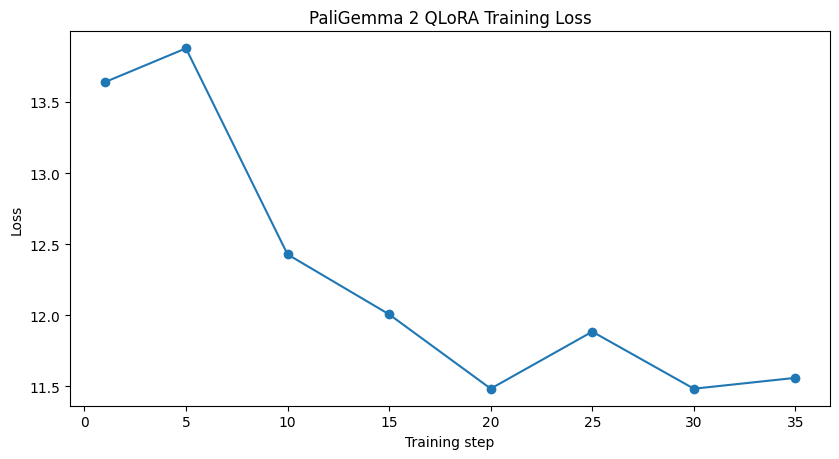

Last training loss: 11.560600280761719


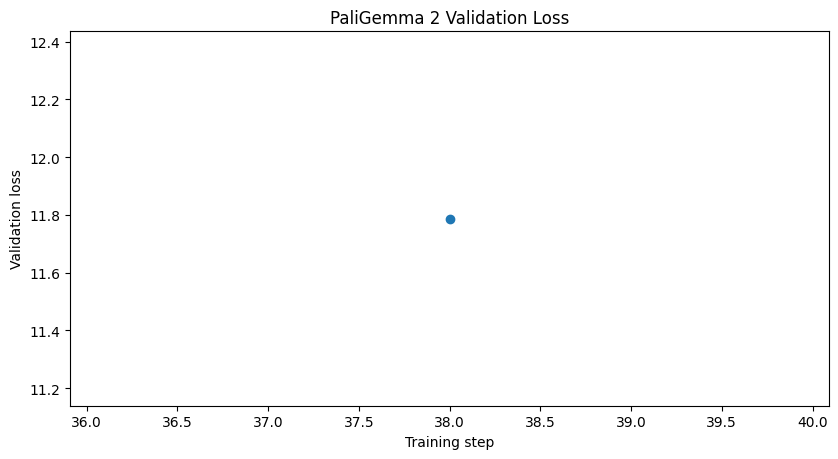

Last validation loss: 11.787281036376953


In [22]:
log_df = pd.DataFrame(trainer.state.log_history)
log_path = OUTPUT_ROOT / "training_log.csv"
log_df.to_csv(log_path, index=False)

print("Training log saved to:", log_path)
print("Number of log rows:", len(log_df))
display(log_df.tail(20))

# Training loss
if "loss" in log_df.columns:
    loss_rows = log_df[log_df["loss"].notna()].copy()
else:
    loss_rows = pd.DataFrame()

if len(loss_rows):
    fig, ax = plt.subplots(figsize=(8.5, 4.7))
    ax.plot(loss_rows["step"], loss_rows["loss"], marker="o")
    ax.set_title("PaliGemma 2 QLoRA Training Loss")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Loss")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "training_loss.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("Last training loss:", loss_rows["loss"].iloc[-1])
else:
    print("No training loss values were logged.")

# Validation loss
if "eval_loss" in log_df.columns:
    eval_rows = log_df[log_df["eval_loss"].notna()].copy()
else:
    eval_rows = pd.DataFrame()

if len(eval_rows):
    fig, ax = plt.subplots(figsize=(8.5, 4.7))
    ax.plot(eval_rows["step"], eval_rows["eval_loss"], marker="o")
    ax.set_title("PaliGemma 2 Validation Loss")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Validation loss")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "validation_loss.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("Last validation loss:", eval_rows["eval_loss"].iloc[-1])
else:
    print("No validation loss values were logged.")

In [23]:
# Token-accuracy graph. Recent TRL versions may log mean_token_accuracy.
train_acc_key = next(
    (k for k in ["mean_token_accuracy", "token_accuracy"]
     if k in log_df.columns),
    None
)
eval_acc_key = next(
    (k for k in ["eval_mean_token_accuracy", "eval_token_accuracy"]
     if k in log_df.columns),
    None
)

token_accuracy_available = False

if train_acc_key is not None:
    train_acc = log_df[log_df[train_acc_key].notna()].copy()
    if len(train_acc):
        token_accuracy_available = True
        fig, ax = plt.subplots(figsize=(8.5, 4.7))
        ax.plot(train_acc["step"], train_acc[train_acc_key])
        ax.set_title("Training Mean Token Accuracy")
        ax.set_xlabel("Training step")
        ax.set_ylabel("Token accuracy")
        ax.set_ylim(0, 1)
        plt.tight_layout()
        fig.savefig(FIGURE_DIR / "training_token_accuracy.png", dpi=180, bbox_inches="tight")
        plt.show()

if eval_acc_key is not None:
    eval_acc = log_df[log_df[eval_acc_key].notna()].copy()
    if len(eval_acc):
        token_accuracy_available = True
        fig, ax = plt.subplots(figsize=(8.5, 4.7))
        ax.plot(eval_acc["step"], eval_acc[eval_acc_key], marker="o")
        ax.set_title("Validation Mean Token Accuracy")
        ax.set_xlabel("Training step")
        ax.set_ylabel("Token accuracy")
        ax.set_ylim(0, 1)
        plt.tight_layout()
        fig.savefig(FIGURE_DIR / "validation_token_accuracy.png", dpi=180, bbox_inches="tight")
        plt.show()

if not token_accuracy_available:
    print(
        "Token accuracy was not logged by this TRL version. "
        "Loss and held-out generation metrics remain the primary model evaluation."
    )


Token accuracy was not logged by this TRL version. Loss and held-out generation metrics remain the primary model evaluation.


In [24]:
validation_metrics = trainer.evaluate()

print(json.dumps(
    {
        k: float(v) if isinstance(v, (int, float, np.number)) else v
        for k, v in validation_metrics.items()
    },
    indent=2
))


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (4304) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


Training Loss,Validation Loss,Epoch
11.560600,11.787281,1


{
  "eval_loss": 11.787281036376953
}


# 9. Fine-Tuned Held-Out Test

The fine-tuned adapter is evaluated on exactly the same test examples as the zero-shot model.


In [25]:
import torch
from peft import PeftModel
from transformers import BitsAndBytesConfig, PaliGemmaForConditionalGeneration

# Re-initialize compute_dtype and quant_config for robustness
compute_dtype = (
    torch.bfloat16 if torch.cuda.is_bf16_supported()
    else torch.float16
)

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)

# Load the base model with the quantization config used during training
base_model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID, # MODEL_ID is defined in cell 8172bc6d
    quantization_config=quant_config,
    device_map={"": 0},
    torch_dtype=compute_dtype,
    token=hf_token, # hf_token is defined in cell 8172bc6d
)

# Load the PEFT adapter from the saved directory
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR) # ADAPTER_DIR is defined in cell 8172bc6d
model.eval()
model.config.use_cache = True

FINETUNED_PATH = OUTPUT_ROOT / "finetuned_test_predictions.csv"

rows = []

for n, (_, row) in enumerate(test_run_df.iterrows(), start=1):
    image_path = DATASET_ROOT / row["image_path"]

    prediction, latency = generate_caption(
        model,
        image_path,
        row["prompt"]
    )

    rows.append({
        "sample_id": row["sample_id"],
        "image_path": row["image_path"],
        "prompt": row["prompt"],
        "reference": row["target_caption"],
        "prediction": prediction,
        "latency_seconds": latency
    })

    if n % 10 == 0 or n == len(test_run_df):
        print(f"Fine-tuned test: {n:,}/{len(test_run_df):,}")

finetuned_df = pd.DataFrame(rows)
finetuned_df.to_csv(FINETUNED_PATH, index=False)

print("Fine-tuned test predictions:", FINETUNED_PATH)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/727 [00:00<?, ?it/s]

Fine-tuned test: 10/100
Fine-tuned test: 20/100
Fine-tuned test: 30/100
Fine-tuned test: 40/100
Fine-tuned test: 50/100
Fine-tuned test: 60/100
Fine-tuned test: 70/100
Fine-tuned test: 80/100
Fine-tuned test: 90/100
Fine-tuned test: 100/100
Fine-tuned test predictions: /kaggle/working/paligemma2_3b_results/finetuned_test_predictions.csv


# 10. Automatic Caption Metrics

No single automatic score measures whether a Ugandan meme is funny or culturally appropriate. These metrics are therefore treated as **complementary indicators**.

Before scoring, both zero-shot and fine-tuned prediction tables are normalized to the same schema:

- `sample_id`
- `image_path`
- `prompt`
- `reference`
- `prediction`
- `latency_seconds`

The validation step also supports older zero-shot outputs that used the legacy column name `zero_shot_prediction`.


In [26]:
import sacrebleu
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer

semantic_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device="cpu"
)

rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def semantic_scores(preds, refs):
    pred_emb = semantic_model.encode(
        list(preds),
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )
    ref_emb = semantic_model.encode(
        list(refs),
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )
    return np.sum(pred_emb * ref_emb, axis=1)

def rouge_l_scores(preds, refs):
    return np.array([
        rouge.score(str(r), str(p))["rougeL"].fmeasure
        for p, r in zip(preds, refs)
    ])

def distinct_n(texts, n=1):
    token_lists = [
        re.findall(r"\b\w+\b", str(t).lower())
        for t in texts
    ]
    ngrams = []
    for tokens in token_lists:
        ngrams.extend(
            tuple(tokens[i:i+n])
            for i in range(len(tokens)-n+1)
        )
    if not ngrams:
        return 0.0
    return len(set(ngrams)) / len(ngrams)

def duplicate_caption_rate(texts):
    normalized = [
        re.sub(r"\s+", " ", str(t).strip().lower())
        for t in texts
    ]
    if not normalized:
        return 0.0
    return 1.0 - (len(set(normalized)) / len(normalized))

def repeated_prefix_rate(texts, prefix_words=3):
    prefixes = []
    for text in texts:
        words = re.findall(r"\b\w+\b", str(text).lower())
        if words:
            prefixes.append(tuple(words[:prefix_words]))
    if not prefixes:
        return 0.0
    return 1.0 - (len(set(prefixes)) / len(prefixes))

def normalize_prediction_schema(frame, frame_name="predictions"):
    """Return a copy using the common `prediction` column."""
    frame = frame.copy()

    if "prediction" not in frame.columns and "zero_shot_prediction" in frame.columns:
        frame = frame.rename(columns={"zero_shot_prediction": "prediction"})
        print(
            f"{frame_name}: renamed legacy column "
            "`zero_shot_prediction` -> `prediction`."
        )

    required = {
        "sample_id",
        "image_path",
        "prompt",
        "reference",
        "prediction",
        "latency_seconds",
    }
    missing = sorted(required - set(frame.columns))

    if missing:
        raise ValueError(
            f"{frame_name} is missing required columns: {missing}. "
            f"Available columns: {frame.columns.tolist()}"
        )

    return frame

def compute_text_metrics(frame, prediction_col="prediction"):
    required = {"reference", prediction_col, "latency_seconds"}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(
            f"Metric computation is missing columns: {missing}. "
            f"Available columns: {frame.columns.tolist()}"
        )

    preds = frame[prediction_col].fillna("").astype(str).tolist()
    refs = frame["reference"].fillna("").astype(str).tolist()

    if not preds:
        raise ValueError("Cannot compute metrics on an empty prediction table.")

    bleu = sacrebleu.corpus_bleu(preds, [refs]).score
    sem = semantic_scores(preds, refs)
    rouge_l = rouge_l_scores(preds, refs)
    lat = frame["latency_seconds"].to_numpy(dtype=float)

    return {
        "BLEU": float(bleu),
        "ROUGE_L": float(np.mean(rouge_l)),
        "Semantic_Cosine": float(np.mean(sem)),
        "Distinct_1": float(distinct_n(preds, 1)),
        "Distinct_2": float(distinct_n(preds, 2)),
        "Duplicate_Caption_Rate": float(duplicate_caption_rate(preds)),
        "Repeated_3Word_Prefix_Rate": float(repeated_prefix_rate(preds, 3)),
        "Latency_Mean_s": float(np.mean(lat)),
        "Latency_Median_s": float(np.median(lat)),
        "Latency_P95_s": float(np.percentile(lat, 95)),
        "Mean_Output_Words": float(np.mean([len(p.split()) for p in preds]))
    }, sem, rouge_l


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [27]:
# Normalize both model states before downstream evaluation.
# This also repairs legacy zero-shot DataFrames created by older notebook versions.
zero_shot_df = normalize_prediction_schema(
    zero_shot_df,
    frame_name="zero_shot_df"
)
finetuned_df = normalize_prediction_schema(
    finetuned_df,
    frame_name="finetuned_df"
)

print("Zero-shot columns:", zero_shot_df.columns.tolist())
print("Fine-tuned columns:", finetuned_df.columns.tolist())

zero_metrics, zero_sem, zero_rouge = compute_text_metrics(zero_shot_df)
ft_metrics, ft_sem, ft_rouge = compute_text_metrics(finetuned_df)

metrics_table = pd.DataFrame([
    {"model_state": "Zero-shot", **zero_metrics},
    {"model_state": "Fine-tuned", **ft_metrics}
])

display(metrics_table)
metrics_table.to_csv(
    OUTPUT_ROOT / "automatic_metrics.csv",
    index=False
)

print("Automatic metrics saved:", OUTPUT_ROOT / "automatic_metrics.csv")


Zero-shot columns: ['sample_id', 'image_path', 'prompt', 'reference', 'prediction', 'latency_seconds']
Fine-tuned columns: ['sample_id', 'image_path', 'prompt', 'reference', 'prediction', 'latency_seconds']


,model_state,BLEU,ROUGE_L,Semantic_Cosine,Distinct_1,Distinct_2,Duplicate_Caption_Rate,Repeated_3Word_Prefix_Rate,Latency_Mean_s,Latency_Median_s,Latency_P95_s,Mean_Output_Words
0,Zero-shot,0.070907,0.027877,0.094142,0.010000,0.010000,0.99,0.99,1.681800,1.681553,1.728865,13.00
1,Fine-tuned,0.059150,0.051216,0.186836,0.168933,0.322282,0.13,0.55,2.660313,2.150737,8.904828,13.59


Automatic metrics saved: /kaggle/working/paligemma2_3b_results/automatic_metrics.csv


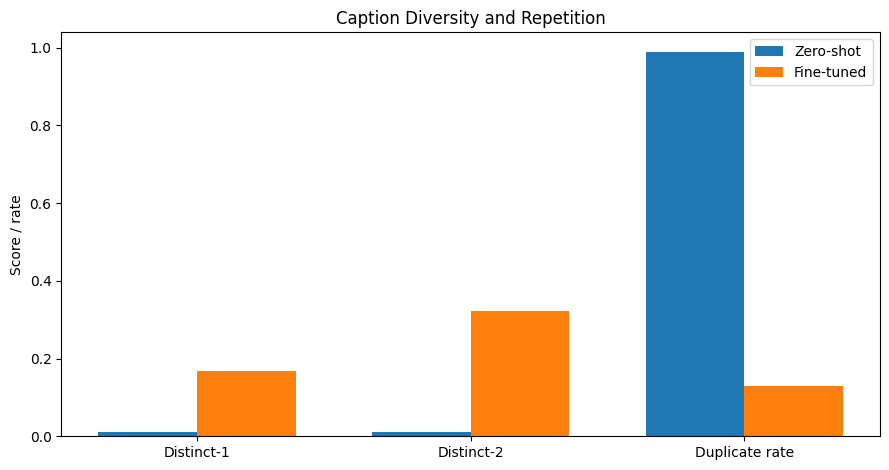

In [28]:
# Sample-level scores support error analysis and group-level analysis.
sample_metrics_df = finetuned_df.copy()
sample_metrics_df["semantic_cosine"] = ft_sem
sample_metrics_df["rouge_l"] = ft_rouge
sample_metrics_df.to_csv(
    OUTPUT_ROOT / "finetuned_sample_level_metrics.csv",
    index=False
)

# Diversity/repetition summary graph.
diversity_plot = pd.DataFrame({
    "metric": ["Distinct-1", "Distinct-2", "Duplicate rate"],
    "Zero-shot": [
        zero_metrics["Distinct_1"],
        zero_metrics["Distinct_2"],
        zero_metrics["Duplicate_Caption_Rate"]
    ],
    "Fine-tuned": [
        ft_metrics["Distinct_1"],
        ft_metrics["Distinct_2"],
        ft_metrics["Duplicate_Caption_Rate"]
    ]
})

x = np.arange(len(diversity_plot))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - width/2, diversity_plot["Zero-shot"], width, label="Zero-shot")
ax.bar(x + width/2, diversity_plot["Fine-tuned"], width, label="Fine-tuned")
ax.set_xticks(x)
ax.set_xticklabels(diversity_plot["metric"])
ax.set_title("Caption Diversity and Repetition")
ax.set_ylabel("Score / rate")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "diversity_repetition.png", dpi=180, bbox_inches="tight")
plt.show()


## 10.1 Confidence Intervals and Paired Significance Test

Bootstrap 95% confidence intervals quantify uncertainty. A paired Wilcoxon signed-rank test compares zero-shot and fine-tuned semantic similarity on the same test samples.


In [29]:
from scipy.stats import wilcoxon

def bootstrap_mean_ci(values, n_boot=2000, confidence=0.95, seed=SEED):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)

    if len(values) == 0:
        return (np.nan, np.nan)

    boot_means = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(sample.mean())

    alpha = (1-confidence)/2
    return (
        float(np.quantile(boot_means, alpha)),
        float(np.quantile(boot_means, 1-alpha))
    )

ci_rows = []
for name, values in [
    ("Zero-shot semantic cosine", zero_sem),
    ("Fine-tuned semantic cosine", ft_sem),
    ("Zero-shot ROUGE-L", zero_rouge),
    ("Fine-tuned ROUGE-L", ft_rouge),
]:
    low, high = bootstrap_mean_ci(values)
    ci_rows.append({
        "metric": name,
        "mean": float(np.mean(values)),
        "ci_95_low": low,
        "ci_95_high": high
    })

ci_df = pd.DataFrame(ci_rows)
display(ci_df)
ci_df.to_csv(OUTPUT_ROOT / "confidence_intervals.csv", index=False)

paired_delta = ft_sem - zero_sem

if len(paired_delta) >= 5 and np.any(np.abs(paired_delta) > 1e-12):
    statistic, p_value = wilcoxon(ft_sem, zero_sem, alternative="two-sided")
else:
    statistic, p_value = np.nan, np.nan

print("Wilcoxon statistic:", statistic)
print("p-value:", p_value)
print("Mean semantic change (fine-tuned - zero-shot):", float(np.mean(paired_delta)))


,metric,mean,ci_95_low,ci_95_high
0,Zero-shot semantic cosine,0.094142,0.075649,0.112056
1,Fine-tuned semantic cosine,0.186836,0.154866,0.221316
2,Zero-shot ROUGE-L,0.027877,0.020076,0.036333
3,Fine-tuned ROUGE-L,0.051216,0.037792,0.065666


Wilcoxon statistic: 1220.0
p-value: 7.222839e-06
Mean semantic change (fine-tuned - zero-shot): 0.09269345551729202


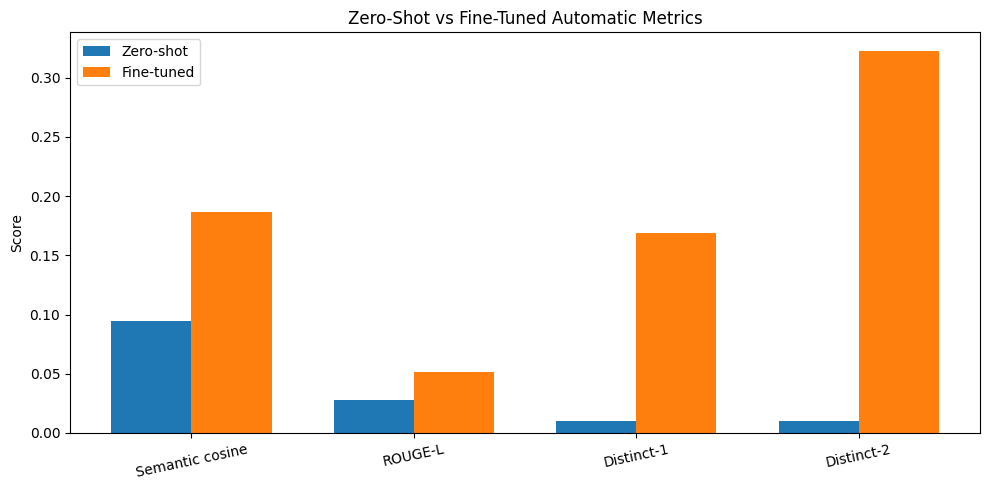

In [30]:
comparison_plot = pd.DataFrame({
    "metric": ["Semantic cosine", "ROUGE-L", "Distinct-1", "Distinct-2"],
    "Zero-shot": [
        zero_metrics["Semantic_Cosine"],
        zero_metrics["ROUGE_L"],
        zero_metrics["Distinct_1"],
        zero_metrics["Distinct_2"]
    ],
    "Fine-tuned": [
        ft_metrics["Semantic_Cosine"],
        ft_metrics["ROUGE_L"],
        ft_metrics["Distinct_1"],
        ft_metrics["Distinct_2"]
    ]
})

x = np.arange(len(comparison_plot))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, comparison_plot["Zero-shot"], width, label="Zero-shot")
ax.bar(x + width/2, comparison_plot["Fine-tuned"], width, label="Fine-tuned")
ax.set_xticks(x)
ax.set_xticklabels(comparison_plot["metric"], rotation=12)
ax.set_title("Zero-Shot vs Fine-Tuned Automatic Metrics")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "automatic_metric_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


# 11. Image–Text Alignment (CLIP Proxy)

CLIP similarity estimates whether the generated caption is aligned with the image. It is **not** a humour score or cultural-appropriateness score.


Loading CLIP: openai/clip-vit-base-patch32


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Zero-shot CLIP: 50/100


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (82 > 77). Running this sequence through the model will result in indexing errors


Zero-shot CLIP: 100/100
Zero-shot CLIP captions truncated to 77 tokens: 0

FINE-TUNED CLIP EVALUATION
Fine-tuned CLIP: 50/100
Fine-tuned CLIP: 100/100
Fine-tuned CLIP captions truncated to 77 tokens: 9

CLIP RESULTS
{
  "zero_shot_clip_mean": 0.19247829526662827,
  "finetuned_clip_mean": 0.25149615421891214
}


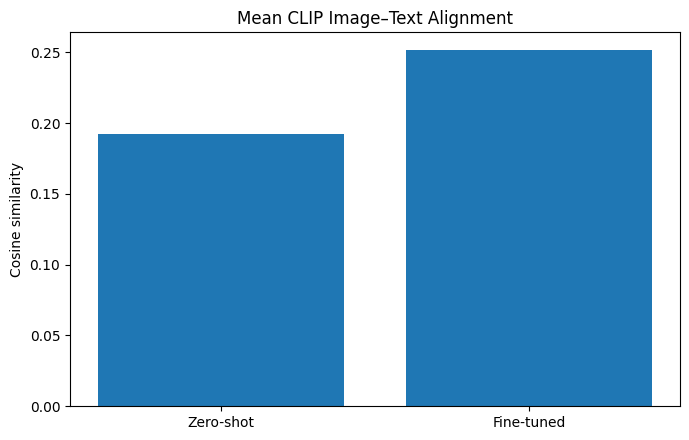

In [31]:
RUN_CLIP_ALIGNMENT = True

clip_results = None
zero_clip = None
ft_clip = None

if RUN_CLIP_ALIGNMENT:

    from transformers import CLIPModel, CLIPProcessor

    CLIP_ID = "openai/clip-vit-base-patch32"
    CLIP_MAX_TOKENS = 77

    print("Loading CLIP:", CLIP_ID)

    clip_processor = CLIPProcessor.from_pretrained(
        CLIP_ID
    )

    clip_model = CLIPModel.from_pretrained(
        CLIP_ID
    ).to("cpu")

    clip_model.eval()


    # -------------------------------------------------------
    # CLIP IMAGE-TEXT ALIGNMENT
    # -------------------------------------------------------

    def clip_alignment(
        frame,
        prediction_col="prediction",
        label="CLIP"
    ):

        if prediction_col not in frame.columns:
            raise ValueError(
                f"CLIP evaluation requires `{prediction_col}`. "
                f"Available columns: {frame.columns.tolist()}"
            )

        scores = []
        truncated_count = 0


        for n, (_, row) in enumerate(
            frame.iterrows(),
            start=1
        ):

            image_path = (
                DATASET_ROOT /
                str(row["image_path"])
            )

            image = Image.open(
                image_path
            ).convert("RGB")


            text = str(
                row[prediction_col]
            ).strip()


            # ------------------------------------------------
            # CHECK ORIGINAL TOKEN LENGTH
            # ------------------------------------------------

            raw_tokens = clip_processor.tokenizer(
                text,
                truncation=False,
                add_special_tokens=True
            )["input_ids"]

            if len(raw_tokens) > CLIP_MAX_TOKENS:
                truncated_count += 1


            # ------------------------------------------------
            # PROCESS IMAGE + TEXT
            #
            # CLIP supports maximum 77 text tokens.
            # Longer generated captions are truncated.
            # ------------------------------------------------

            inputs = clip_processor(
                text=[text],
                images=[image],
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=CLIP_MAX_TOKENS
            )


            with torch.inference_mode():

                outputs = clip_model(
                    **inputs
                )

                image_emb = outputs.image_embeds
                text_emb = outputs.text_embeds


                # L2 normalization
                image_emb = (
                    image_emb /
                    image_emb.norm(
                        dim=-1,
                        keepdim=True
                    )
                )

                text_emb = (
                    text_emb /
                    text_emb.norm(
                        dim=-1,
                        keepdim=True
                    )
                )


                # Cosine similarity
                score = (
                    image_emb *
                    text_emb
                ).sum(
                    dim=-1
                ).item()


            scores.append(score)


            if (
                n % 50 == 0
                or n == len(frame)
            ):
                print(
                    f"{label}: "
                    f"{n}/{len(frame)}"
                )


        print(
            f"{label} captions truncated "
            f"to {CLIP_MAX_TOKENS} tokens:",
            truncated_count
        )


        return np.array(
            scores,
            dtype=float
        )


    # -------------------------------------------------------
    # RUN BOTH AGAIN USING EXACTLY THE SAME CLIP SETTINGS
    # -------------------------------------------------------

    print("\nZERO-SHOT CLIP EVALUATION")
    zero_clip = clip_alignment(
        zero_shot_df,
        prediction_col="prediction",
        label="Zero-shot CLIP"
    )


    print("\nFINE-TUNED CLIP EVALUATION")
    ft_clip = clip_alignment(
        finetuned_df,
        prediction_col="prediction",
        label="Fine-tuned CLIP"
    )


    # -------------------------------------------------------
    # SUMMARY
    # -------------------------------------------------------

    clip_results = {

        "zero_shot_clip_mean":
            float(
                np.mean(zero_clip)
            ),

        "finetuned_clip_mean":
            float(
                np.mean(ft_clip)
            )
    }


    print("\nCLIP RESULTS")
    print("=" * 60)

    print(
        json.dumps(
            clip_results,
            indent=2
        )
    )


    # -------------------------------------------------------
    # SAVE FINE-TUNED SAMPLE-LEVEL VALUES
    # -------------------------------------------------------

    sample_metrics_df[
        "clip_alignment"
    ] = ft_clip


    sample_metrics_df.to_csv(
        OUTPUT_ROOT /
        "finetuned_sample_level_metrics.csv",
        index=False
    )


    # -------------------------------------------------------
    # VISUAL COMPARISON
    # -------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7, 4.5)
    )


    ax.bar(
        [
            "Zero-shot",
            "Fine-tuned"
        ],
        [
            clip_results[
                "zero_shot_clip_mean"
            ],
            clip_results[
                "finetuned_clip_mean"
            ]
        ]
    )


    ax.set_title(
        "Mean CLIP Image–Text Alignment"
    )

    ax.set_ylabel(
        "Cosine similarity"
    )


    plt.tight_layout()


    fig.savefig(
        FIGURE_DIR /
        "clip_alignment.png",
        dpi=180,
        bbox_inches="tight"
    )


    plt.show()


    # -------------------------------------------------------
    # CLEANUP
    # -------------------------------------------------------

    del clip_model
    del clip_processor

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# 12. Performance by Ugandan Context Category and Language

If your CSV already contains category/language labels, the notebook calculates subgroup performance automatically. If not, it exports a simple annotation template instead of failing.

This section can reveal, for example, whether PaliGemma performs better on transport memes than political memes, or better in English than code-switched/local-language captions.


In [32]:
CATEGORY_CANDIDATES = [
    "category", "meme_category", "context_category", "topic", "domain"
]
LANGUAGE_CANDIDATES = [
    "language", "caption_language", "lang"
]
OBJECTIVE_CANDIDATES = [
    "communication_objective", "communicative_objective",
    "objective", "intent"
]

def first_existing(columns, candidates):
    return next((c for c in candidates if c in columns), None)

category_col = first_existing(test_run_df.columns, CATEGORY_CANDIDATES)
language_col = first_existing(test_run_df.columns, LANGUAGE_CANDIDATES)
objective_col = first_existing(test_run_df.columns, OBJECTIVE_CANDIDATES)

print("Detected category column:", category_col)
print("Detected language column:", language_col)
print("Detected objective column:", objective_col)

analysis_base = sample_metrics_df.merge(
    test_run_df,
    on=["sample_id", "image_path"],
    how="left",
    suffixes=("", "_dataset")
)

def subgroup_summary(frame, group_col):
    rows = []
    for group_value, group in frame.dropna(subset=[group_col]).groupby(group_col):
        rows.append({
            group_col: group_value,
            "n": len(group),
            "semantic_cosine_mean": group["semantic_cosine"].mean(),
            "rouge_l_mean": group["rouge_l"].mean(),
            "clip_alignment_mean": (
                group["clip_alignment"].mean()
                if "clip_alignment" in group.columns
                else np.nan
            )
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)

if category_col:
    category_results = subgroup_summary(analysis_base, category_col)
    display(category_results)
    category_results.to_csv(
        OUTPUT_ROOT / "performance_by_category.csv",
        index=False
    )
else:
    category_results = pd.DataFrame()
    print("No category label found. An annotation template will be exported.")

if language_col:
    language_results = subgroup_summary(analysis_base, language_col)
    display(language_results)
    language_results.to_csv(
        OUTPUT_ROOT / "performance_by_language.csv",
        index=False
    )
else:
    language_results = pd.DataFrame()
    print("No language label found. An annotation template will be exported.")

if not category_col or not language_col:
    annotation_template = finetuned_df[
        ["sample_id", "image_path", "prompt", "reference", "prediction"]
    ].copy()

    if not category_col:
        annotation_template["category"] = ""
    if not language_col:
        annotation_template["language"] = ""
    if not objective_col:
        annotation_template["communication_objective"] = ""

    annotation_template.to_csv(
        OUTPUT_ROOT / "context_annotation_template.csv",
        index=False
    )
    display(annotation_template.head())


Detected category column: None
Detected language column: None
Detected objective column: None
No category label found. An annotation template will be exported.
No language label found. An annotation template will be exported.


,sample_id,image_path,prompt,reference,prediction,category,language,communication_objective
0,UGMEME_000014,images/UGMEME_000014.jpg,"Generate a short, culturally relevant Ugandan ...",~Isnt Kenya Just sending it's people to Uganda...,When you are in a relationship but you don't k...,,,
1,UGMEME_000049,images/UGMEME_000049.jpg,"Generate a short, culturally relevant Ugandan ...",Police and Army Thieves in Kla fire out break ...,"Me: ""Me: Me: Me: Me: Me: Me: Me: Me: Me: Me: M...",,,
2,UGMEME_000057,images/UGMEME_000057.jpg,"Generate a short, culturally relevant Ugandan ...",bino sibyange Kemircthe Junior,When you are in a relationship but you don't w...,,,
3,UGMEME_000074,images/UGMEME_000074.jpg,"Generate a short, culturally relevant Ugandan ...",2016 STARTED WITHA GORILLA AND ENDED WITH A GU...,When you are sleeping but you have a dream abo...,,,
4,UGMEME_000110,images/UGMEME_000110.jpg,"Generate a short, culturally relevant Ugandan ...",EXPLOITED and LEFT BROKE? MANAGER ACCUSED 0F S...,UGANDAN CHILD STAR TENG TENG,,,


# 13. Common Meme Renderer

A model comparison should not let one model benefit from a better graphics engine than another. Therefore all five VLMs should use the **same renderer**.

This renderer:

- wraps long captions;
- automatically reduces font size until the text fits;
- chooses the less visually busy top/bottom region;
- places a high-contrast translucent text panel;
- records font size, position, text-area occupancy and overflow status.

These rendering measurements evaluate the graphics pipeline; they do not replace human judgement of layout quality.


In [33]:
def find_bold_font():
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf",
    ]
    for path in candidates:
        if Path(path).exists():
            return path
    return None

FONT_PATH = find_bold_font()

def region_visual_complexity(image, region="top"):
    gray = np.asarray(image.convert("L"), dtype=np.float32)
    h = gray.shape[0]
    band = gray[:max(1, h//3), :] if region == "top" else gray[-max(1, h//3):, :]
    # Higher standard deviation approximates a busier region.
    return float(np.std(band))

def choose_position(image):
    top_complexity = region_visual_complexity(image, "top")
    bottom_complexity = region_visual_complexity(image, "bottom")
    return (
        ("top", top_complexity, bottom_complexity)
        if top_complexity <= bottom_complexity
        else ("bottom", top_complexity, bottom_complexity)
    )

def wrap_for_font(draw, text, font, max_width):
    words = str(text).strip().split()
    if not words:
        return [""]

    lines = []
    current = words[0]

    for word in words[1:]:
        candidate = current + " " + word
        bbox = draw.textbbox((0, 0), candidate, font=font, stroke_width=2)
        width = bbox[2] - bbox[0]

        if width <= max_width:
            current = candidate
        else:
            lines.append(current)
            current = word

    lines.append(current)
    return lines

def fit_caption(image, caption):
    w, h = image.size
    max_width = int(w * 0.90)
    max_text_height = int(h * 0.34)

    scratch = Image.new("RGB", (w, h))
    draw = ImageDraw.Draw(scratch)

    start_size = max(18, int(min(w, h) * 0.09))
    min_size = max(14, int(min(w, h) * 0.035))

    for font_size in range(start_size, min_size - 1, -2):
        font = (
            ImageFont.truetype(FONT_PATH, font_size)
            if FONT_PATH
            else ImageFont.load_default()
        )

        lines = wrap_for_font(draw, caption, font, max_width)
        line_boxes = [
            draw.textbbox((0, 0), line, font=font, stroke_width=2)
            for line in lines
        ]
        line_heights = [box[3] - box[1] for box in line_boxes]
        line_spacing = max(4, int(font_size * 0.18))
        total_height = sum(line_heights) + line_spacing * max(0, len(lines)-1)
        max_line_width = max((box[2] - box[0] for box in line_boxes), default=0)

        if total_height <= max_text_height and max_line_width <= max_width:
            return {
                "font": font,
                "font_size": font_size,
                "lines": lines,
                "text_height": total_height,
                "max_line_width": max_line_width,
                "overflow": False,
                "line_spacing": line_spacing,
            }

    font = (
        ImageFont.truetype(FONT_PATH, min_size)
        if FONT_PATH
        else ImageFont.load_default()
    )
    lines = wrap_for_font(draw, caption, font, max_width)
    boxes = [draw.textbbox((0, 0), line, font=font, stroke_width=2) for line in lines]
    heights = [b[3] - b[1] for b in boxes]
    line_spacing = max(4, int(min_size * 0.18))
    total_height = sum(heights) + line_spacing * max(0, len(lines)-1)

    return {
        "font": font,
        "font_size": min_size,
        "lines": lines,
        "text_height": total_height,
        "max_line_width": max((b[2] - b[0] for b in boxes), default=0),
        "overflow": total_height > max_text_height,
        "line_spacing": line_spacing,
    }

def render_meme(source_path, caption, output_path):
    image = Image.open(source_path).convert("RGB")
    w, h = image.size

    fit = fit_caption(image, caption)
    position, top_complexity, bottom_complexity = choose_position(image)

    rgba = image.convert("RGBA")
    overlay = Image.new("RGBA", rgba.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    padding_x = int(w * 0.04)
    padding_y = max(10, int(h * 0.02))
    panel_height = min(
        int(h * 0.40),
        fit["text_height"] + 2 * padding_y
    )

    if position == "top":
        y0 = 0
        y1 = panel_height
        text_y = padding_y
    else:
        y0 = h - panel_height
        y1 = h
        text_y = y0 + padding_y

    draw.rectangle(
        (0, y0, w, y1),
        fill=(0, 0, 0, 175)
    )

    current_y = text_y

    for line in fit["lines"]:
        bbox = draw.textbbox(
            (0, 0),
            line,
            font=fit["font"],
            stroke_width=2
        )
        line_w = bbox[2] - bbox[0]
        line_h = bbox[3] - bbox[1]
        x = (w - line_w) / 2

        draw.text(
            (x, current_y),
            line,
            font=fit["font"],
            fill=(255, 255, 255, 255),
            stroke_width=2,
            stroke_fill=(0, 0, 0, 255)
        )

        current_y += line_h + fit["line_spacing"]

    rendered = Image.alpha_composite(rgba, overlay).convert("RGB")
    rendered.save(output_path, quality=95)

    text_area_ratio = (
        (fit["max_line_width"] * fit["text_height"]) / (w * h)
        if w * h else np.nan
    )

    return {
        "position": position,
        "font_size_px": fit["font_size"],
        "line_count": len(fit["lines"]),
        "text_area_ratio": float(text_area_ratio),
        "overflow": bool(fit["overflow"]),
        "top_visual_complexity": top_complexity,
        "bottom_visual_complexity": bottom_complexity,
        "rendered_width": w,
        "rendered_height": h,
    }


In [34]:
render_rows = []

for n, (_, row) in enumerate(finetuned_df.iterrows(), start=1):
    source_path = DATASET_ROOT / row["image_path"]
    safe_id = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(row["sample_id"]))
    output_path = RENDER_DIR / f"{safe_id}.jpg"

    render_stats = render_meme(
        source_path,
        row["prediction"],
        output_path
    )

    render_rows.append({
        "sample_id": row["sample_id"],
        "image_path": row["image_path"],
        "rendered_meme_path": str(output_path),
        **render_stats
    })

    if n % 50 == 0 or n == len(finetuned_df):
        print(f"Rendered: {n}/{len(finetuned_df)}")

rendering_df = pd.DataFrame(render_rows)
rendering_df.to_csv(OUTPUT_ROOT / "rendering_metrics.csv", index=False)

display(rendering_df.describe(include="all").T)

print("Overflow rate:", rendering_df["overflow"].mean())
print("Mean text-area ratio:", rendering_df["text_area_ratio"].mean())


Rendered: 50/100
Rendered: 100/100


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sample_id,100,100,UGMEME_000014,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_path,100,100,images/UGMEME_000014.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rendered_meme_path,100,100,/kaggle/working/paligemma2_3b_results/rendered...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
position,100,2,top,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
font_size_px,100.0,NaN,NaN,NaN,44.92,20.962053,18.0,30.0,38.0,50.75,111.0
line_count,100.0,NaN,NaN,NaN,1.17,0.450701,1.0,1.0,1.0,1.0,4.0
text_area_ratio,100.0,NaN,NaN,NaN,0.022322,0.032302,0.000352,0.006109,0.012026,0.020743,0.182347
overflow,100,1,False,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top_visual_complexity,100.0,NaN,NaN,NaN,53.696042,25.179007,0.0,35.087828,56.366053,69.860828,121.705231
bottom_visual_complexity,100.0,NaN,NaN,NaN,59.552246,19.759184,0.428986,48.887156,59.384043,71.643116,119.442047


Overflow rate: 0.0
Mean text-area ratio: 0.022321569576981795


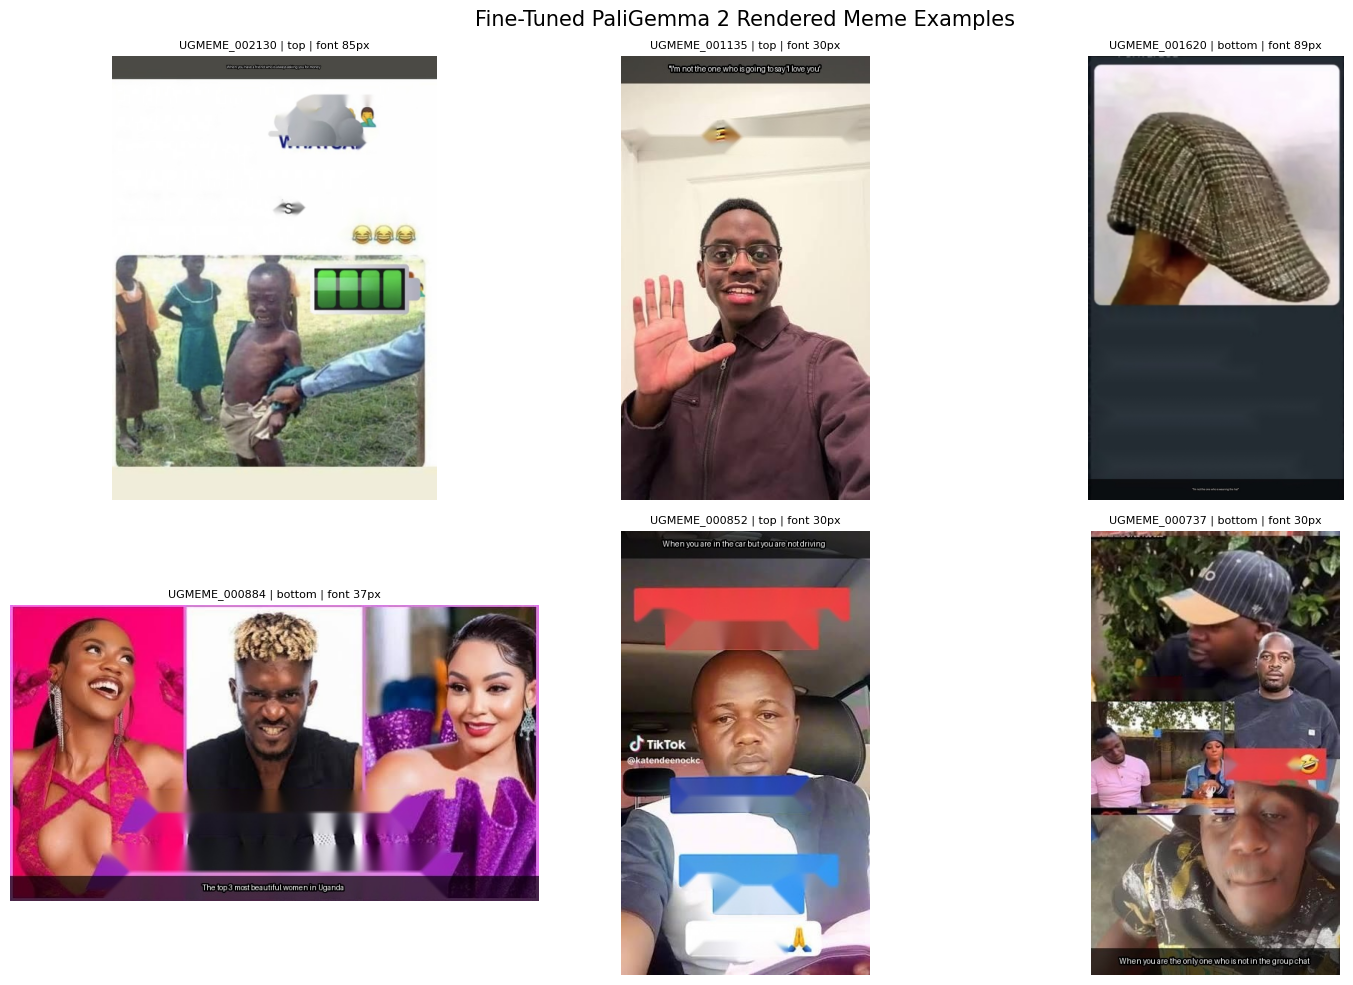

In [35]:
# Small rendered-meme gallery for qualitative inspection.
gallery = rendering_df.sample(
    min(6, len(rendering_df)),
    random_state=SEED
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for ax, (_, row) in zip(axes, gallery.iterrows()):
    image = Image.open(row["rendered_meme_path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(
        f"{row['sample_id']} | {row['position']} | font {row['font_size_px']}px",
        fontsize=8
    )
    ax.axis("off")

fig.suptitle("Fine-Tuned PaliGemma 2 Rendered Meme Examples", fontsize=15)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "rendered_meme_gallery.png", dpi=180, bbox_inches="tight")
plt.show()


# 14. Human Evaluation: Humour, Culture and Meme Success Rate

Automatic metrics cannot establish whether a meme is funny, culturally appropriate or communicatively effective.

The notebook exports a **three-rater template**. Each selected meme appears once for each rater slot.

### Rating scale

Use 1–5:

- 1 = very poor
- 2 = poor
- 3 = acceptable/moderate
- 4 = good
- 5 = excellent

### Meme Success Rate

For each meme, ratings are averaged across raters. A meme is classified as successful only if it reaches **all predefined thresholds** in `SUCCESS_THRESHOLDS`.

\[
	ext{Meme Success Rate} =

rac{	ext{number of successful memes}}
{	ext{number of rated memes}} 	imes 100
\]

This is a clearer project-level percentage than calling BLEU or CLIP “accuracy.”


In [36]:
human_n = min(HUMAN_EVAL_N, len(finetuned_df))

human_sample = finetuned_df.sample(
    human_n,
    random_state=SEED
).merge(
    rendering_df[["sample_id", "rendered_meme_path"]],
    on="sample_id",
    how="left"
)

if objective_col and objective_col in test_run_df.columns:
    objective_lookup = test_run_df[["sample_id", objective_col]].copy()
    objective_lookup = objective_lookup.rename(
        columns={objective_col: "communication_objective"}
    )
    human_sample = human_sample.merge(
        objective_lookup,
        on="sample_id",
        how="left"
    )
else:
    human_sample["communication_objective"] = ""

base_cols = [
    "sample_id",
    "image_path",
    "rendered_meme_path",
    "prompt",
    "communication_objective",
    "reference",
    "prediction"
]

human_rows = []

for rater_slot in range(1, N_RATER_SLOTS + 1):
    temp = human_sample[base_cols].copy()
    temp["rater_slot"] = rater_slot
    temp["rater_id"] = ""
    human_rows.append(temp)

human_eval = pd.concat(human_rows, ignore_index=True)

rating_columns = [
    "visual_relevance_1_5",
    "ugandan_cultural_appropriateness_1_5",
    "humour_1_5",
    "communicative_effectiveness_1_5",
    "typography_readability_1_5",
    "layout_quality_1_5",
    "overall_quality_1_5",
]

for col in rating_columns:
    human_eval[col] = ""

human_eval["comments"] = ""

HUMAN_TEMPLATE_PATH = OUTPUT_ROOT / "human_evaluation_template.csv"
HUMAN_COMPLETED_PATH = OUTPUT_ROOT / "human_evaluation_completed.csv"

human_eval.to_csv(HUMAN_TEMPLATE_PATH, index=False)

print("Human evaluation template:", HUMAN_TEMPLATE_PATH)
print(
    "After rating, save the completed file as:",
    HUMAN_COMPLETED_PATH
)
display(human_eval.head(9))


Human evaluation template: /kaggle/working/paligemma2_3b_results/human_evaluation_template.csv
After rating, save the completed file as: /kaggle/working/paligemma2_3b_results/human_evaluation_completed.csv


,sample_id,image_path,rendered_meme_path,prompt,communication_objective,reference,prediction,rater_slot,rater_id,visual_relevance_1_5,ugandan_cultural_appropriateness_1_5,humour_1_5,communicative_effectiveness_1_5,typography_readability_1_5,layout_quality_1_5,overall_quality_1_5,comments
0,UGMEME_002130,images/UGMEME_002130.jpg,/kaggle/working/paligemma2_3b_results/rendered...,"Generate a short, culturally relevant Ugandan ...",,TEACHER: Name six Animals that live WFI inside...,When you have a friend who is always asking yo...,1,,,,,,,,,
1,UGMEME_001135,images/UGMEME_001135.jpg,/kaggle/working/paligemma2_3b_results/rendered...,"Generate a short, culturally relevant Ugandan ...",,Funniest memes part six,"""I'm not the one who is going to say 'I love you'",1,,,,,,,,,
2,UGMEME_001620,images/UGMEME_001620.jpg,/kaggle/working/paligemma2_3b_results/rendered...,"Generate a short, culturally relevant Ugandan ...",,"Apart from joblessness, Selling family lands, ...","""I'm not the one who is wearing the hat""",1,,,,,,,,,
3,UGMEME_000884,images/UGMEME_000884.jpg,/kaggle/working/paligemma2_3b_results/rendered...,"Generate a short, culturally relevant Ugandan ...",,20 Most Famous Ugandan Celebrities,The top 3 most beautiful women in Uganda,1,,,,,,,,,
4,UGMEME_000852,images/UGMEME_000852.jpg,/kaggle/working/paligemma2_3b_results/rendered...,"Generate a short, culturally relevant Ugandan ...",,Nga wakazukuka Soka osabe mukama Proverbs 3:6 ...,When you are in the car but you are not driving,1,,,,,,,,,
5,UGMEME_000737,images/UGMEME_000737.jpg,/kaggle/working/paligemma2_3b_results/rendered...,"Generate a short, culturally relevant Ugandan ...",,Swimer MEDIA the end,When you are the only one who is not in the gr...,1,,,,,,,,,
6,UGMEME_000411,images/UGMEME_000411.jpg,/kaggle/working/paligemma2_3b_results/rendered...,"Generate a short, culturally relevant Ugandan ...",,My body is my journal and my tattoos are my st...,"""I'm not the one who's been in the room""",1,,,,,,,,,
7,UGMEME_002048,images/UGMEME_002048.jpg,/kaggle/working/paligemma2_3b_results/rendered...,"Generate a short, culturally relevant Ugandan ...",,MTN Uganda watching your data bundle expire af...,MTN,1,,,,,,,,,
8,UGMEME_000212,images/UGMEME_000212.jpg,/kaggle/working/paligemma2_3b_results/rendered...,"Generate a short, culturally relevant Ugandan ...",,Ugandan How East African Wives serve their hus...,When you are in a relationship but you don't w...,1,,,,,,,,,


In [37]:
# This cell calculates human scores only after the completed CSV exists.
human_results = {
    "Humour_Mean": np.nan,
    "Culture_Mean": np.nan,
    "Visual_Relevance_Mean": np.nan,
    "Communicative_Effectiveness_Mean": np.nan,
    "Typography_Readability_Mean": np.nan,
    "Layout_Quality_Mean": np.nan,
    "Overall_Quality_Mean": np.nan,
    "Meme_Success_Rate_pct": np.nan,
    "Rated_Memes": 0,
}

if HUMAN_COMPLETED_PATH.exists():
    completed = pd.read_csv(HUMAN_COMPLETED_PATH)

    for col in rating_columns:
        completed[col] = pd.to_numeric(completed[col], errors="coerce")

    valid = completed.dropna(subset=rating_columns).copy()

    if len(valid) == 0:
        print("Completed human-evaluation file exists, but no fully rated rows were found.")
    else:
        sample_means = valid.groupby("sample_id")[rating_columns].mean()

        success_mask = np.ones(len(sample_means), dtype=bool)
        for col, threshold in SUCCESS_THRESHOLDS.items():
            success_mask &= sample_means[col].to_numpy() >= threshold

        human_results = {
            "Humour_Mean": float(sample_means["humour_1_5"].mean()),
            "Culture_Mean": float(
                sample_means["ugandan_cultural_appropriateness_1_5"].mean()
            ),
            "Visual_Relevance_Mean": float(
                sample_means["visual_relevance_1_5"].mean()
            ),
            "Communicative_Effectiveness_Mean": float(
                sample_means["communicative_effectiveness_1_5"].mean()
            ),
            "Typography_Readability_Mean": float(
                sample_means["typography_readability_1_5"].mean()
            ),
            "Layout_Quality_Mean": float(
                sample_means["layout_quality_1_5"].mean()
            ),
            "Overall_Quality_Mean": float(
                sample_means["overall_quality_1_5"].mean()
            ),
            "Meme_Success_Rate_pct": float(100 * success_mask.mean()),
            "Rated_Memes": int(len(sample_means)),
        }

        display(pd.DataFrame([human_results]))

        fig, ax = plt.subplots(figsize=(9, 4.8))
        labels = [
            "Humour", "Culture", "Visual relevance",
            "Communication", "Readability", "Layout", "Overall"
        ]
        values = [
            human_results["Humour_Mean"],
            human_results["Culture_Mean"],
            human_results["Visual_Relevance_Mean"],
            human_results["Communicative_Effectiveness_Mean"],
            human_results["Typography_Readability_Mean"],
            human_results["Layout_Quality_Mean"],
            human_results["Overall_Quality_Mean"],
        ]
        ax.bar(labels, values)
        ax.set_ylim(0, 5)
        ax.set_ylabel("Mean human rating (1–5)")
        ax.set_title(
            f"Human Evaluation | Meme Success Rate = "
            f"{human_results['Meme_Success_Rate_pct']:.1f}%"
        )
        ax.tick_params(axis="x", rotation=25)
        plt.tight_layout()
        fig.savefig(FIGURE_DIR / "human_evaluation_summary.png", dpi=180, bbox_inches="tight")
        plt.show()
else:
    print(
        "Human evaluation is not completed yet. "
        "Fill human_evaluation_template.csv, save it as "
        "human_evaluation_completed.csv, then rerun this cell and the final results cells."
    )


Human evaluation is not completed yet. Fill human_evaluation_template.csv, save it as human_evaluation_completed.csv, then rerun this cell and the final results cells.


# 15. Focused Error Analysis

Instead of a large explainability section, this experiment keeps a practical error-analysis table for the lowest-scoring generated captions. Human reviewers can classify why the failures occurred.


In [38]:
error_analysis_df = sample_metrics_df.sort_values(
    "semantic_cosine",
    ascending=True
).head(min(50, len(sample_metrics_df))).copy()

for col in [
    "wrong_visual_interpretation",
    "generic_caption",
    "cultural_mismatch",
    "too_literal",
    "too_long",
    "repetitive_pattern",
    "unsafe_or_inappropriate",
    "other_error",
    "reviewer_notes"
]:
    error_analysis_df[col] = ""

error_analysis_df.to_csv(
    OUTPUT_ROOT / "error_analysis_template.csv",
    index=False
)

display(
    error_analysis_df[
        ["sample_id", "reference", "prediction", "semantic_cosine", "rouge_l"]
    ].head(15)
)


,sample_id,reference,prediction,semantic_cosine,rouge_l
1,UGMEME_000049,Police and Army Thieves in Kla fire out break ...,"Me: ""Me: Me: Me: Me: Me: Me: Me: Me: Me: Me: M...",-0.098161,0.000000
12,UGMEME_000235,Drinking and driving Sober designated driver s...,When you are in a relationship but you don't k...,-0.093760,0.000000
0,UGMEME_000014,~Isnt Kenya Just sending it's people to Uganda...,When you are in a relationship but you don't k...,-0.086352,0.068966
32,UGMEME_000604,DryBones Ec362320' Entebbe Dayl Happy TONS,The 1976 and 2018 versions of the cartoon are ...,-0.070575,0.000000
74,UGMEME_001745,My wife checking on the homework helped our da...,When you are in a relationship but you are sti...,-0.067695,0.071429
2,UGMEME_000057,bino sibyange Kemircthe Junior,When you are in a relationship but you don't w...,-0.055627,0.000000
41,UGMEME_000771,Me pale class 6 after kupata 32/40 insha Yaitw...,When you are in a relationship but you are sti...,-0.055576,0.000000
92,UGMEME_002387,Real Madrid lineup for the next season,"""I'm not the same person I was before you were...",-0.052498,0.105263
83,UGMEME_002130,TEACHER: Name six Animals that live WFI inside...,When you have a friend who is always asking yo...,-0.046275,0.000000
38,UGMEME_000715,gettyimages Credic Romulo Rejon,The Uganda police have arrested 10 people for ...,-0.038579,0.000000


# 16. Efficiency Measurements

For model comparison, report speed and hardware cost alongside quality.


In [39]:
# -----------------------------------------------------------
# RECORD PEFT / LoRA PARAMETER STATISTICS
# -----------------------------------------------------------

# PEFT provides a better parameter count for quantized models
if hasattr(model, "get_nb_trainable_parameters"):
    trainable_params, total_params = model.get_nb_trainable_parameters()
else:
    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

peft_param_stats = {
    "trainable_parameters": int(trainable_params),
    "total_parameters": int(total_params),
    "trainable_percent": float(
        100 * trainable_params / total_params
    ),
}

print("PEFT parameter statistics")
print("=" * 60)
print(
    "Trainable LoRA parameters:",
    f"{peft_param_stats['trainable_parameters']:,}"
)
print(
    "Total parameters:",
    f"{peft_param_stats['total_parameters']:,}"
)
print(
    "Trainable percentage:",
    f"{peft_param_stats['trainable_percent']:.4f}%"
)

PEFT parameter statistics
Trainable LoRA parameters: 0
Total parameters: 3,055,995,120
Trainable percentage: 0.0000%


In [40]:
def directory_size_mb(path):
    total = 0
    for p in Path(path).rglob("*"):
        if p.is_file():
            total += p.stat().st_size
    return total / 1024**2

adapter_size_mb = directory_size_mb(ADAPTER_DIR)

efficiency_results = {
    "base_total_parameters": base_parameter_stats["total_parameters"],
    "trainable_lora_parameters": peft_param_stats["trainable_parameters"],
    "trainable_percent": peft_param_stats["trainable_percent"],
    "adapter_size_mb": adapter_size_mb,
    "training_minutes": train_elapsed / 60,
    "peak_gpu_allocated_gb": peak_gpu_gb,
    "finetuned_mean_latency_s": ft_metrics["Latency_Mean_s"],
    "finetuned_p95_latency_s": ft_metrics["Latency_P95_s"],
}

display(pd.DataFrame(
    [{"efficiency_metric": k, "value": v}
     for k, v in efficiency_results.items()]
))


,efficiency_metric,value
0,base_total_parameters,1.813242e+09
1,trainable_lora_parameters,0.000000e+00
2,trainable_percent,0.000000e+00
3,adapter_size_mb,1.236899e+02
4,training_minutes,9.522569e+00
5,peak_gpu_allocated_gb,7.044751e+00
6,finetuned_mean_latency_s,2.660313e+00
7,finetuned_p95_latency_s,8.904828e+00


# 17. Standardized Final PaliGemma 2 Results

This is the most important export for the later five-model comparison. The same column names should be produced by every model notebook.


In [41]:
fine_tuned_clip_mean = (
    clip_results["finetuned_clip_mean"]
    if clip_results is not None
    else np.nan
)

zero_shot_clip_mean = (
    clip_results["zero_shot_clip_mean"]
    if clip_results is not None
    else np.nan
)

results_rows = []

for state, metrics, clip_value in [
    ("zero_shot", zero_metrics, zero_shot_clip_mean),
    ("fine_tuned", ft_metrics, fine_tuned_clip_mean),
]:
    row = {
        "Model": MODEL_LABEL,
        "Experiment": EXPERIMENT_NAME,
        "State": state,
        "Run_Mode": RUN_MODE,
        "Test_Samples": len(test_run_df),
        "BLEU": metrics["BLEU"],
        "ROUGE_L": metrics["ROUGE_L"],
        "Semantic_Cosine": metrics["Semantic_Cosine"],
        "CLIP_Alignment": clip_value,
        "Distinct_1": metrics["Distinct_1"],
        "Distinct_2": metrics["Distinct_2"],
        "Duplicate_Caption_Rate": metrics["Duplicate_Caption_Rate"],
        "Repeated_3Word_Prefix_Rate": metrics["Repeated_3Word_Prefix_Rate"],
        "Mean_Latency_s": metrics["Latency_Mean_s"],
        "P95_Latency_s": metrics["Latency_P95_s"],
        "Mean_Output_Words": metrics["Mean_Output_Words"],
    }

    if state == "fine_tuned":
        row.update({
            **human_results,
            "Render_Overflow_Rate": float(rendering_df["overflow"].mean()),
            "Mean_Text_Area_Ratio": float(rendering_df["text_area_ratio"].mean()),
            "Training_Minutes": float(efficiency_results["training_minutes"]),
            "Peak_GPU_GB": float(efficiency_results["peak_gpu_allocated_gb"]),
            "Adapter_Size_MB": float(efficiency_results["adapter_size_mb"]),
            "Trainable_Percent": float(efficiency_results["trainable_percent"]),
            "Wilcoxon_Semantic_p": (
                None if pd.isna(p_value) else float(p_value)
            ),
        })

    results_rows.append(row)

metrics_summary_df = pd.DataFrame(results_rows)

metrics_summary_df.to_csv(
    OUTPUT_ROOT / "metrics_summary.csv",
    index=False
)

with open(
    OUTPUT_ROOT / "metrics_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metrics_summary_df.where(
            pd.notnull(metrics_summary_df), None
        ).to_dict(orient="records"),
        f,
        indent=2
    )

display(metrics_summary_df.T)


,0,1
Model,PaliGemma 2 3B Mix 224,PaliGemma 2 3B Mix 224
Experiment,paligemma2_3b_mix224_ugmeme,paligemma2_3b_mix224_ugmeme
State,zero_shot,fine_tuned
Run_Mode,reduced,reduced
Test_Samples,100,100
BLEU,0.070907,0.05915
ROUGE_L,0.027877,0.051216
Semantic_Cosine,0.094142,0.186836
CLIP_Alignment,0.192478,0.251496
Distinct_1,0.01,0.168933


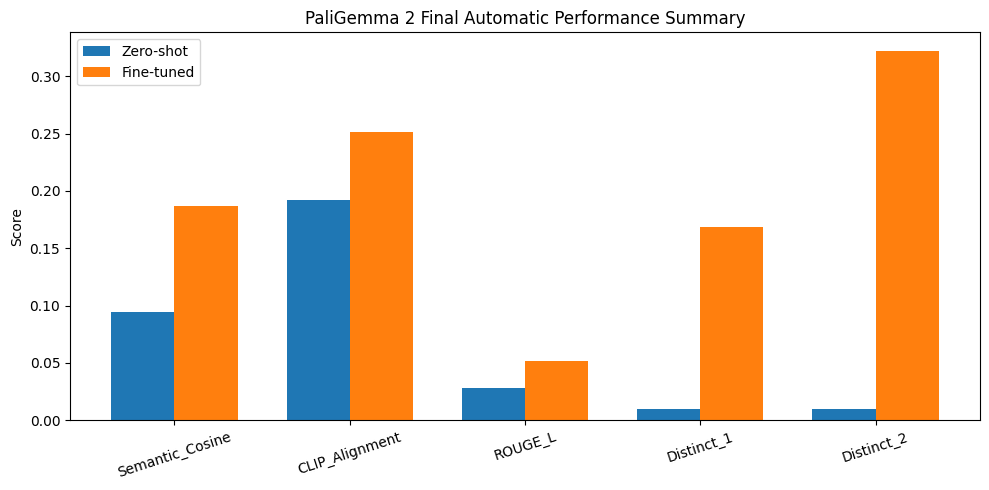

In [42]:
# Compact graph for documentation: key automatic metrics.
key_metric_names = ["Semantic_Cosine", "CLIP_Alignment", "ROUGE_L", "Distinct_1", "Distinct_2"]

zero_row = metrics_summary_df[
    metrics_summary_df["State"] == "zero_shot"
].iloc[0]

ft_row = metrics_summary_df[
    metrics_summary_df["State"] == "fine_tuned"
].iloc[0]

plot_df = pd.DataFrame({
    "Metric": key_metric_names,
    "Zero-shot": [zero_row[m] for m in key_metric_names],
    "Fine-tuned": [ft_row[m] for m in key_metric_names]
})

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, plot_df["Zero-shot"], width, label="Zero-shot")
ax.bar(x + width/2, plot_df["Fine-tuned"], width, label="Fine-tuned")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Metric"], rotation=18)
ax.set_ylabel("Score")
ax.set_title("PaliGemma 2 Final Automatic Performance Summary")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "final_paligemma_performance_summary.png", dpi=180, bbox_inches="tight")
plt.show()


# 18. Experiment Manifest

The manifest records exactly which dataset, software, hardware and training configuration produced the reported result.


In [43]:
experiment_manifest = {
    "experiment_name": EXPERIMENT_NAME,
    "base_model": MODEL_ID,
    "run_mode": RUN_MODE,
    "random_seed": SEED,
    "dataset_hashes": dataset_hashes,
    "dataset_sizes_original": {
        "train": len(train_df),
        "validation": len(val_df),
        "test": len(test_df)
    },
    "dataset_sizes_run": {
        "train": len(train_run_df),
        "validation": len(val_run_df),
        "test": len(test_run_df)
    },
    "training_hyperparameters": training_hyperparameters,
    "parameter_efficiency": peft_param_stats,
    "efficiency_results": efficiency_results,
    "validation_metrics": {
        k: (
            float(v)
            if isinstance(v, (int, float, np.number))
            else str(v)
        )
        for k, v in validation_metrics.items()
    },
    "human_success_thresholds": SUCCESS_THRESHOLDS,
    "human_results": {
        k: (None if pd.isna(v) else v)
        for k, v in human_results.items()
    },
    "software": {
        "python": sys.version.split()[0],
        "pytorch": torch.__version__,
        "transformers": transformers.__version__,
        "datasets": datasets.__version__,
        "peft": peft.__version__,
        "trainer_backend": "transformers.Trainer",
        "bitsandbytes": bnb.__version__,
    },
    "hardware": {
        "gpu": torch.cuda.get_device_name(0),
        "gpu_total_memory_gb": round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            3
        )
    }
}

with open(
    OUTPUT_ROOT / "experiment_manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(experiment_manifest, f, indent=2)

print("Experiment manifest saved.")


Experiment manifest saved.


# 19. Final Readiness Check


In [44]:
required_outputs = [
    OUTPUT_ROOT / "zero_shot_test_predictions.csv",
    OUTPUT_ROOT / "finetuned_test_predictions.csv",
    OUTPUT_ROOT / "automatic_metrics.csv",
    OUTPUT_ROOT / "finetuned_sample_level_metrics.csv",
    OUTPUT_ROOT / "confidence_intervals.csv",
    OUTPUT_ROOT / "rendering_metrics.csv",
    OUTPUT_ROOT / "human_evaluation_template.csv",
    OUTPUT_ROOT / "error_analysis_template.csv",
    OUTPUT_ROOT / "metrics_summary.csv",
    OUTPUT_ROOT / "metrics_summary.json",
    OUTPUT_ROOT / "training_log.csv",
    OUTPUT_ROOT / "experiment_manifest.json",
]

missing = [str(p) for p in required_outputs if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Required experiment artifacts are missing:\n" + "\n".join(missing)
    )

print("=" * 76)
print("PALIGEMMA 2 UGMEME EXPERIMENT COMPLETED")
print("=" * 76)
print("Checkpoint:", MODEL_ID)
print("Run mode:", RUN_MODE)
print("Results:", OUTPUT_ROOT)

if RUN_MODE == "reduced":
    print(
        "\nIMPORTANT: This is REDUCED MODE for pipeline checking. "
        "Do not report reduced-mode values as final dissertation results."
    )
    print(
        'For the final experiment, set RUN_MODE = "full", '
        "restart the Kaggle session and run the notebook from the beginning."
    )
else:
    print(
        "\nFULL MODE completed. Preserve this notebook version, "
        "metrics_summary.csv, experiment_manifest.json and the figures."
    )

if not HUMAN_COMPLETED_PATH.exists():
    print(
        "\nHuman evaluation is still pending. Automatic results are complete, "
        "but Meme Success Rate, humour and cultural scores require Ugandan raters."
    )


PALIGEMMA 2 UGMEME EXPERIMENT COMPLETED
Checkpoint: google/paligemma2-3b-mix-224
Run mode: reduced
Results: /kaggle/working/paligemma2_3b_results

IMPORTANT: This is REDUCED MODE for pipeline checking. Do not report reduced-mode values as final dissertation results.
For the final experiment, set RUN_MODE = "full", restart the Kaggle session and run the notebook from the beginning.

Human evaluation is still pending. Automatic results are complete, but Meme Success Rate, humour and cultural scores require Ugandan raters.


# 20. What to Report in the Dissertation

For **PaliGemma 2**, report:

### Checkpoint and training
- exact checkpoint (`google/paligemma2-3b-mix-224` unless deliberately changed);
- full train/validation/test sizes and CSV hashes;
- 224×224 model resolution;
- QLoRA configuration;
- number and percentage of trainable parameters;
- training time and peak GPU memory;
- training and validation loss;
- token-accuracy curve only if the installed trainer records it.

### Held-out automatic evaluation
- BLEU;
- ROUGE-L;
- semantic cosine similarity;
- CLIP image–text alignment;
- Distinct-1 and Distinct-2;
- duplicate-caption rate;
- mean and P95 inference latency;
- 95% confidence intervals;
- zero-shot vs fine-tuned Wilcoxon test.

### Rendered meme evaluation
- renderer overflow rate;
- typography/readability human score;
- layout-quality human score.

### Ugandan human evaluation
- humour;
- Ugandan cultural appropriateness;
- visual relevance;
- communicative effectiveness;
- overall quality;
- **Meme Success Rate**.

### Subgroup analysis
When category/language labels are available, compare performance across Ugandan contexts and languages.

## Final five-model comparison

Use the same held-out split, renderer, human-rating protocol and metric definitions for every model:

| Model | Semantic ↑ | CLIP ↑ | Humour ↑ | Culture ↑ | Visual relevance ↑ | Communication ↑ | Readability ↑ | Layout ↑ | Meme success ↑ | Diversity ↑ | Latency ↓ | Peak VRAM ↓ |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Qwen2.5-VL | measured | measured | human | human | human | human | human | human | human | measured | measured | measured |
| PaliGemma 2 | measured | measured | human | human | human | human | human | human | human | measured | measured | measured |
| InternVL2.5 | measured | measured | human | human | human | human | human | human | human | measured | measured | measured |
| LLaVA-OneVision | measured | measured | human | human | human | human | human | human | human | measured | measured | measured |
| MiniCPM-V | measured | measured | human | human | human | human | human | human | human | measured | measured | measured |

The strongest model is not necessarily the one with the highest BLEU. The final selection should combine **semantic quality, visual grounding, Ugandan cultural/humour ratings, rendering quality and computational efficiency**.
